# Skin Sample Analysis Notebook

## Configs and Metrics

In [80]:
# Load compact profiles produced by window_sequence_analysis/run_svm_prediction.py
from __future__ import annotations

import re
import sys
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import MaxNLocator

plt.style.use("seaborn-v0_8-whitegrid")


def repo_root_from_here() -> Path:
    here = Path.cwd().resolve()
    for path in (here, *here.parents):
        if (path / "window_sequence_analysis").is_dir():
            return path
    raise FileNotFoundError("Could not locate the repository root.")


def resolve_data_dir(root: Path, data_dir: str) -> Path:
    path = Path(data_dir)
    resolved = path if path.is_absolute() else (root / path)
    resolved = resolved.resolve()
    if not resolved.is_dir():
        raise FileNotFoundError(f"Data directory not found: {resolved}")
    return resolved


def latest_profile_csv(data_dir: Path) -> Path:
    filename = "window_sequence_profiles.csv"
    results_root = data_dir / "results"
    run_profiles = list((results_root / "runs").glob(f"*/{filename}"))
    if run_profiles:
        return max(run_profiles, key=lambda path: path.stat().st_mtime_ns)
    legacy_profile = results_root / filename
    if legacy_profile.is_file():
        return legacy_profile
    raise FileNotFoundError(
        f"No {filename} found in {results_root / 'runs'} or {results_root}. "
        "Set DATA_DIR to the input data folder (e.g. data/skin_samples)."
    )


ROOT = repo_root_from_here()
DATA_DIR = "data/skin_samples"
DATA_PATH = resolve_data_dir(ROOT, DATA_DIR)
RESULTS_ROOT = DATA_PATH / "results"
PROFILES_CSV = latest_profile_csv(DATA_PATH)

CLUSTER_COL = "single_cell_expression_cluster"
DELIMITER_COL = "profile_delimiter"
UNASSIGNED_LABEL = "(unassigned)"

PROFILE_AGGREGATION_MODE = "mean"  # "max" or "mean"

PROFILE_GRID = 200
MAX_OVERLAY_TRACES = 40
INCLUDE_UNASSIGNED = False
CLUSTER_SUBSTRING: str | None = None
MAX_CLUSTERS: int | None = None
CLUSTER_ORDER_BY = "prevalence"
CLUSTER_ORDER_DESCENDING = True
EXPECTED_CLUSTER_COUNT: int | None = 108

def sigma_for_p_amp(p_amp: float, svm_pkl: Path) -> float:
    """Invert the SVM Platt fit so a P(AMP) decision boundary becomes a sigma."""
    if not 0.0 < p_amp < 1.0:
        raise ValueError(f"P_AMP_FITTING must be between 0 and 1, got {p_amp}.")
    if str(ROOT) not in sys.path:
        sys.path.insert(0, str(ROOT))
    from window_sequence_analysis.models.svm import load_svm

    svm = load_svm(svm_pkl)
    classes = np.asarray(getattr(svm, "classes_", []))
    if classes.size != 2 or int(classes[-1]) != 1:
        raise ValueError(f"Expected a binary SVM with positive class 1, got classes {classes}.")
    prob_a = float(np.asarray(svm.probA_).ravel()[0])
    prob_b = float(np.asarray(svm.probB_).ravel()[0])
    if prob_a == 0.0:
        raise ValueError("SVM Platt slope probA_ is 0, so P(AMP) cannot be mapped to sigma.")
    # sklearn's binary decision_function is the negated libsvm margin.
    # P(AMP) = 1 / (1 + exp(probA * sigma - probB)).
    return float((np.log((1.0 - p_amp) / p_amp) + prob_b) / prob_a)


def activity_boundary_label() -> str:
    sigma_text = f"σNGC > {SIGMA_ACTIVITY_THRESHOLD:.2f}"
    if P_AMP_FITTING is None:
        return f"Threshold {sigma_text}"
    return f"Threshold P > {P_AMP_FITTING:g} / {sigma_text}"


# P(AMP) activity boundary. None keeps AUC and plots at sigma = 0.
# 0.8 is inverted through the SVM Platt fit to the matching sigma.
P_AMP_FITTING: float | None = None
SVM_PKL = ROOT / "checkpoints" / "svm_no_class_weight" / "svm_qsar12_model.pkl"
SIGMA_ACTIVITY_THRESHOLD = 0.0 if P_AMP_FITTING is None else sigma_for_p_amp(P_AMP_FITTING, SVM_PKL)
P_AMP_ACTIVITY_THRESHOLD: float | None = None
# Proteins with DNGC (A / S) below this are dropped before every table and plot.
# None keeps every protein. A protein equal to the threshold is kept.
DNGC_MIN_THRESHOLD: float | None = None
PLOT_PREVIEW_LIMIT: int | None = 16
PLOT_GRID_ROWS = 4
PLOT_GRID_COLUMNS = 4
# True uses one y-limit for every histogram panel. False lets each panel autoscale.
SCALE_HISTOGRAM_Y = False
SAVE_ALL_CLUSTER_PLOTS = True
SAVE_DPI = 200
CLUSTER_PLOT_DIR = RESULTS_ROOT / "dngc_cluster_plots"

print("ROOT:", ROOT)
print("data dir:", DATA_PATH)
print("profiles:", PROFILES_CSV)
print("activity rule:", activity_boundary_label())
print("P(AMP) threshold:", P_AMP_ACTIVITY_THRESHOLD or "not applied")
print("DNGC minimum:", "not applied" if DNGC_MIN_THRESHOLD is None else DNGC_MIN_THRESHOLD)
print("shared histogram y-axis:", "on" if SCALE_HISTOGRAM_Y else "off")
print(
    "save cluster plots:",
    f"{CLUSTER_PLOT_DIR} (all clusters, 4x4 pages)" if SAVE_ALL_CLUSTER_PLOTS else "off",
)


ROOT: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction
data dir: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/data/skin_samples
profiles: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/data/skin_samples/results/runs/2026-09-16_20-47/window_sequence_profiles.csv
activity rule: Threshold σNGC > 0.00
P(AMP) threshold: not applied
DNGC minimum: not applied
shared histogram y-axis: off
save cluster plots: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/data/skin_samples/results/dngc_cluster_plots (all clusters, 4x4 pages)


In [81]:
# load the input csv into an in-memory object to group by cluster


def parse_profile(text: object, delimiter: str = ";") -> np.ndarray:
    parts = str(text).split(delimiter or ";")
    values = np.empty(len(parts), dtype=np.float64)
    for index, part in enumerate(parts):
        token = part.strip()
        values[index] = np.nan if not token or token.lower() == "nan" else float(token)
    return values


def cluster_label(value: object) -> str:
    text = "" if pd.isna(value) else str(value).strip()
    return text or UNASSIGNED_LABEL


def cluster_sort_key(name: str) -> tuple[int, int, str]:
    match = re.match(r"Cluster\s+(\d+)", name)
    if match:
        return (0, int(match.group(1)), name)
    if name == UNASSIGNED_LABEL:
        return (2, 0, name)
    return (1, 0, name)


def short_cluster_label(name: str, max_len: int = 48) -> str:
    text = name[len("Cluster ") :] if name.startswith("Cluster ") else name
    if len(text) <= max_len:
        return text
    return text[: max_len - 3] + "..."


def activity_mask(sigma: np.ndarray, p_amp: np.ndarray) -> np.ndarray:
    mask = np.isfinite(sigma) & (sigma > SIGMA_ACTIVITY_THRESHOLD)
    if P_AMP_ACTIVITY_THRESHOLD is not None:
        mask &= np.isfinite(p_amp) & (p_amp > P_AMP_ACTIVITY_THRESHOLD)
    return mask


def count_fragments(active: np.ndarray) -> int:
    if active.size == 0 or not np.any(active):
        return 0
    padded = np.concatenate([[False], np.asarray(active, dtype=bool)])
    return int(np.count_nonzero(padded[1:] & ~padded[:-1]))


@dataclass(frozen=True)
class ActivityStatistics:
    s_score: int
    fragment_count: int
    potency_auc: float
    coverage: float
    dngc: float


def calculate_activity_statistics(
    sigma: np.ndarray,
    p_amp: np.ndarray,
    sequence_length: int,
) -> ActivityStatistics:
    active = activity_mask(sigma, p_amp)
    s_score = int(np.count_nonzero(active))
    fragment_count = count_fragments(active)
    excess = sigma[active] - SIGMA_ACTIVITY_THRESHOLD
    potency_auc = float(np.sum(excess)) if s_score else 0.0
    coverage = s_score / sequence_length if sequence_length else 0.0
    mean_dngc = potency_auc / s_score if s_score else 0.0
    return ActivityStatistics(
        s_score=s_score,
        fragment_count=fragment_count,
        potency_auc=potency_auc,
        coverage=coverage,
        dngc=mean_dngc,
    )


def interpolate_profile(sigma: np.ndarray, grid: int = PROFILE_GRID) -> np.ndarray:
    finite = np.isfinite(sigma)
    if not np.any(finite):
        return np.full(grid, np.nan, dtype=np.float64)
    x = np.linspace(0.0, 1.0, len(sigma))
    xp = np.linspace(0.0, 1.0, grid)
    filled = np.nan_to_num(sigma, nan=0.0)
    return np.interp(xp, x, filled)


MEAN_SIGMA_COLUMN = "hyperplane_distance_mean_profile"
MEAN_P_AMP_COLUMN = "p_amp_mean_profile"


@dataclass
class SequenceProfile:
    id: str
    name: str
    cluster: str
    sequence_length: int
    sigma: np.ndarray
    p_amp: np.ndarray
    statistics: ActivityStatistics
    mean_profile_has_activity: bool
    best_window_p_amp: float
    best_window_hyperplane_distance: float

    @property
    def relative_sigma(self) -> np.ndarray:
        return interpolate_profile(self.sigma)


def _finite_values(values: list[float]) -> np.ndarray:
    finite = np.asarray(values, dtype=np.float64)
    return finite[np.isfinite(finite)]


def _mean_finite(values: list[float]) -> float:
    finite = _finite_values(values)
    return float(np.mean(finite)) if finite.size else float("nan")


def _max_finite(values: list[float]) -> float:
    finite = _finite_values(values)
    return float(np.max(finite)) if finite.size else float("nan")


def _median_finite(values: list[float]) -> float:
    finite = _finite_values(values)
    return float(np.median(finite)) if finite.size else float("nan")


@dataclass
class ClusterGroup:
    name: str
    profiles: list[SequenceProfile] = field(default_factory=list)

    @property
    def n(self) -> int:
        return len(self.profiles)

    @property
    def prevalence(self) -> float:
        return float(np.mean([item.statistics.s_score > 0 for item in self.profiles]))

    @property
    def mean_profile_prevalence(self) -> float:
        return float(np.mean([item.mean_profile_has_activity for item in self.profiles]))

    @property
    def mean_s_score(self) -> float:
        return _mean_finite([item.statistics.s_score for item in self.profiles])

    @property
    def mean_fragment_count(self) -> float:
        return _mean_finite([item.statistics.fragment_count for item in self.profiles])

    @property
    def mean_potency(self) -> float:
        return _mean_finite([item.statistics.potency_auc for item in self.profiles])

    @property
    def max_potency(self) -> float:
        return _max_finite([item.statistics.potency_auc for item in self.profiles])

    @property
    def mean_coverage(self) -> float:
        return _mean_finite([item.statistics.coverage for item in self.profiles])

    @property
    def mean_dngc(self) -> float:
        return _mean_finite([item.statistics.dngc for item in self.profiles])

    @property
    def median_dngc(self) -> float:
        return _median_finite([item.statistics.dngc for item in self.profiles])

    @property
    def curvature_load(self) -> float:
        total_length = sum(item.sequence_length for item in self.profiles)
        if not total_length:
            return float("nan")
        total_auc = sum(item.statistics.potency_auc for item in self.profiles)
        return total_auc / total_length

    @property
    def mean_best_window_p_amp(self) -> float:
        return _mean_finite([item.best_window_p_amp for item in self.profiles])

    @property
    def mean_best_window_distance(self) -> float:
        return _mean_finite([item.best_window_hyperplane_distance for item in self.profiles])

    @property
    def rank_score(self) -> float:
        metrics = {
            "prevalence": self.mean_profile_prevalence,
            "mean_DNGC": self.mean_dngc,
            "median_DNGC": self.median_dngc,
            "mean_A": self.mean_potency,
            "max_A": self.max_potency,
            "curvature_load": self.curvature_load,
            "mean_S": self.mean_s_score,
            "mean_N": self.mean_fragment_count,
            "best_window_p_amp": self.mean_best_window_p_amp,
            "best_window_hyperplane_distance": self.mean_best_window_distance,
        }
        if CLUSTER_ORDER_BY not in metrics:
            raise ValueError(f"Unsupported cluster ordering metric: {CLUSTER_ORDER_BY}")
        return metrics[CLUSTER_ORDER_BY]

    def stacked_relative_sigma(self) -> np.ndarray:
        if not self.profiles:
            return np.empty((0, PROFILE_GRID), dtype=np.float64)
        return np.vstack([item.relative_sigma for item in self.profiles])


def load_profile_table(path: Path) -> tuple[pd.DataFrame, str, str]:
    if not path.is_file():
        raise FileNotFoundError(f"Window profile CSV not found: {path}")
    frame = pd.read_csv(path)
    required = {"id", "sequence_length", DELIMITER_COL, CLUSTER_COL}
    missing = sorted(required - set(frame.columns))
    if missing:
        raise ValueError(f"Profile CSV missing columns: {missing}")
    if frame.empty:
        raise ValueError(f"Window profile CSV is empty: {path}")
        
    sigma_col = f"hyperplane_distance_{PROFILE_AGGREGATION_MODE}_profile"
    p_amp_col = f"p_amp_{PROFILE_AGGREGATION_MODE}_profile"
    ranking_cols = {MEAN_SIGMA_COLUMN, MEAN_P_AMP_COLUMN}
    missing_profiles = sorted({sigma_col, p_amp_col, *ranking_cols} - set(frame.columns))
    if missing_profiles:
        raise ValueError(f"Profile CSV missing required profile columns: {missing_profiles}.")
        
    return frame, sigma_col, p_amp_col


def build_cluster_groups(
    frame: pd.DataFrame,
    sigma_column: str,
    p_amp_column: str,
    *,
    cluster_names: set[str] | None = None,
    limit: int | None = MAX_CLUSTERS,
) -> list[ClusterGroup]:
    grouped: dict[str, ClusterGroup] = {}
    for row in frame.itertuples(index=False):
        label = cluster_label(getattr(row, CLUSTER_COL))
        if label == UNASSIGNED_LABEL and not INCLUDE_UNASSIGNED:
            continue
        if cluster_names is not None and label not in cluster_names:
            continue
        if CLUSTER_SUBSTRING and CLUSTER_SUBSTRING.casefold() not in label.casefold():
            continue
        delimiter = str(getattr(row, DELIMITER_COL) or ";")
        sigma = parse_profile(getattr(row, sigma_column), delimiter)
        p_amp = parse_profile(getattr(row, p_amp_column), delimiter)
        mean_sigma = parse_profile(getattr(row, MEAN_SIGMA_COLUMN), delimiter)
        mean_p_amp = parse_profile(getattr(row, MEAN_P_AMP_COLUMN), delimiter)
        sequence_length = int(getattr(row, "sequence_length"))
        if len(sigma) != sequence_length or len(p_amp) != sequence_length:
            raise ValueError(f"{row.id}: profile length does not match sequence_length={sequence_length}.")
        if len(mean_sigma) != sequence_length or len(mean_p_amp) != sequence_length:
            raise ValueError(f"{row.id}: mean profile length does not match sequence_length={sequence_length}.")
        mean_profile_stats = calculate_activity_statistics(mean_sigma, mean_p_amp, sequence_length)
        profile = SequenceProfile(
            id=str(getattr(row, "id")),
            name=str(getattr(row, "name", "") or "").strip(),
            cluster=label,
            sequence_length=sequence_length,
            sigma=sigma,
            p_amp=p_amp,
            statistics=calculate_activity_statistics(sigma, p_amp, sequence_length),
            mean_profile_has_activity=mean_profile_stats.s_score > 0,
            best_window_p_amp=_row_float(row, "best_window_p_amp"),
            best_window_hyperplane_distance=_row_float(row, "best_window_hyperplane_distance"),
        )
        grouped.setdefault(label, ClusterGroup(name=label)).profiles.append(profile)

    def order_key(group: ClusterGroup) -> tuple[bool, float, tuple[int, int, str]]:
        score = group.rank_score
        if not np.isfinite(score):
            return (True, 0.0, cluster_sort_key(group.name))
        ordered_score = -score if CLUSTER_ORDER_DESCENDING else score
        return (False, ordered_score, cluster_sort_key(group.name))

    groups = sorted(grouped.values(), key=order_key)
    if limit is not None:
        groups = groups[: max(0, int(limit))]
    return groups


def _row_float(row: object, column: str) -> float:
    if not hasattr(row, column):
        return float("nan")
    try:
        value = float(getattr(row, column))
    except (TypeError, ValueError):
        return float("nan")
    return value if np.isfinite(value) else float("nan")


def protein_dngc(row: pd.Series, sigma_column: str, p_amp_column: str) -> float:
    delimiter = str(row[DELIMITER_COL] or ";")
    sigma = parse_profile(row[sigma_column], delimiter)
    p_amp = parse_profile(row[p_amp_column], delimiter)
    sequence_length = int(row["sequence_length"])
    return calculate_activity_statistics(sigma, p_amp, sequence_length).dngc


def exclude_proteins_below_dngc(
    frame: pd.DataFrame,
    sigma_column: str,
    p_amp_column: str,
) -> pd.DataFrame:
    if DNGC_MIN_THRESHOLD is None:
        print("DNGC minimum: not applied")
        return frame
    scores = frame.apply(lambda row: protein_dngc(row, sigma_column, p_amp_column), axis=1)
    kept = frame.loc[scores >= DNGC_MIN_THRESHOLD].reset_index(drop=True)
    excluded = len(frame) - len(kept)
    print(
        f"DNGC minimum {DNGC_MIN_THRESHOLD:g}: excluded {excluded:,} of {len(frame):,} proteins "
        f"with DNGC < {DNGC_MIN_THRESHOLD:g}"
    )
    return kept


profiles_df, sigma_profile_column, p_amp_profile_column = load_profile_table(PROFILES_CSV)
profiles_df = exclude_proteins_below_dngc(profiles_df, sigma_profile_column, p_amp_profile_column)
clusters = build_cluster_groups(profiles_df, sigma_profile_column, p_amp_profile_column)
n_sequences = sum(group.n for group in clusters)
print(f"Loaded {n_sequences:,} proteins in {len(clusters):,} clusters from {PROFILES_CSV.name}")
print("σ profile:", sigma_profile_column)
print("P(AMP) profile:", p_amp_profile_column)
print(f"cluster order: {CLUSTER_ORDER_BY} ({PROFILE_AGGREGATION_MODE} aggregation)")
if EXPECTED_CLUSTER_COUNT is not None and len(clusters) != EXPECTED_CLUSTER_COUNT:
    print(f"Warning: expected {EXPECTED_CLUSTER_COUNT} clusters but found {len(clusters)}.")


DNGC minimum: not applied
Loaded 4,601 proteins in 110 clusters from window_sequence_profiles.csv
σ profile: hyperplane_distance_mean_profile
P(AMP) profile: p_amp_mean_profile
cluster order: prevalence (mean aggregation)


In [82]:
def protein_statistics_table(groups: list[ClusterGroup]) -> pd.DataFrame:
    rows = []
    for cluster_order, group in enumerate(groups):
        for item in group.profiles:
            stats = item.statistics
            rows.append(
                {
                    "_cluster_order": cluster_order,
                    "id": item.id,
                    "name": item.name,
                    CLUSTER_COL: item.cluster,
                    "cluster_prevalence": group.prevalence,
                    "protein_length": item.sequence_length,
                    "S_score": stats.s_score,
                    "N_fragment_count": stats.fragment_count,
                    "has_activity": stats.s_score > 0,
                    "A_potency_auc": stats.potency_auc,
                    "F_coverage": stats.coverage,
                    "DNGC": stats.dngc,
                }
            )
    table = pd.DataFrame(rows).sort_values(
        ["_cluster_order", "DNGC"],
        ascending=[True, False],
        ignore_index=True,
    )
    return table.drop(columns="_cluster_order")


def median_metric(group: ClusterGroup, attribute: str) -> float:
    values = [getattr(item.statistics, attribute) for item in group.profiles]
    return float(np.median(values))


def cluster_statistics_table(groups: list[ClusterGroup]) -> pd.DataFrame:
    table = pd.DataFrame(
        {
            CLUSTER_COL: [group.name for group in groups],
            "protein_count": [group.n for group in groups],
            "prevalence": [group.prevalence for group in groups],
            "mean_S": [group.mean_s_score for group in groups],
            "median_S": [median_metric(group, "s_score") for group in groups],
            "mean_N": [group.mean_fragment_count for group in groups],
            "median_N": [median_metric(group, "fragment_count") for group in groups],
            "mean_A": [group.mean_potency for group in groups],
            "median_A": [median_metric(group, "potency_auc") for group in groups],
            "max_A": [group.max_potency for group in groups],
            "curvature_load": [group.curvature_load for group in groups],
            "mean_F": [group.mean_coverage for group in groups],
            "median_F": [median_metric(group, "coverage") for group in groups],
            "mean_DNGC": [group.mean_dngc for group in groups],
            "median_DNGC": [group.median_dngc for group in groups],
            "mean_best_window_p_amp": [group.mean_best_window_p_amp for group in groups],
            "mean_best_window_distance": [group.mean_best_window_distance for group in groups],
        }
    )
    return table


protein_statistics = protein_statistics_table(clusters)
cluster_statistics = cluster_statistics_table(clusters)
print(f"Per-protein statistics ({len(protein_statistics)} proteins):")
display(protein_statistics)
print(f"Cluster statistics ({len(cluster_statistics)} clusters):")
display(cluster_statistics)


Per-protein statistics (4601 proteins):


,id,name,single_cell_expression_cluster,cluster_prevalence,protein_length,S_score,N_fragment_count,has_activity,A_potency_auc,F_coverage,DNGC
0,sp|Q8NHH9|ATLA2_HUMAN,Atlastin-2,Cluster 19: Cerebellar purkinje cells - Neurot...,1.000000,583,32,2,True,14.614654,0.054889,0.456708
1,sp|O15020|SPTN2_HUMAN,"Spectrin beta chain, non-erythrocytic 2",Cluster 19: Cerebellar purkinje cells - Neurot...,1.000000,2390,42,3,True,17.598408,0.017573,0.419010
2,sp|P51649|SSDH_HUMAN,"Succinate-semialdehyde dehydrogenase, mitochon...",Cluster 109: Neurons - Neuronal signaling,0.800000,535,30,1,True,25.175347,0.056075,0.839178
3,sp|P35612|ADDB_HUMAN,Beta-adducin,Cluster 109: Neurons - Neuronal signaling,0.800000,726,25,1,True,14.820997,0.034435,0.592840
4,sp|O00533|NCHL1_HUMAN,Neural cell adhesion molecule L1-like protein,Cluster 109: Neurons - Neuronal signaling,0.800000,1208,22,1,True,11.826999,0.018212,0.537591
...,...,...,...,...,...,...,...,...,...,...,...
4596,sp|Q96J42|TXD15_HUMAN,Thioredoxin domain-containing protein 15,Cluster 67: Plasma cells - Plasma cell differe...,0.170732,360,0,0,False,0.000000,0.000000,0.000000
4597,sp|Q8NBS9|TXND5_HUMAN,Thioredoxin domain-containing protein 5,Cluster 67: Plasma cells - Plasma cell differe...,0.170732,432,0,0,False,0.000000,0.000000,0.000000
4598,sp|P61960|UFM1_HUMAN,Ubiquitin-fold modifier 1,Cluster 67: Plasma cells - Plasma cell differe...,0.170732,85,0,0,False,0.000000,0.000000,0.000000
4599,sp|Q93084|AT2A3_HUMAN,Sarcoplasmic/endoplasmic reticulum calcium ATP...,Cluster 95: Tuft cells - Chemosensory signaling,0.000000,999,0,0,False,0.000000,0.000000,0.000000


Cluster statistics (110 clusters):


,single_cell_expression_cluster,protein_count,prevalence,mean_S,median_S,mean_N,median_N,mean_A,median_A,max_A,curvature_load,mean_F,median_F,mean_DNGC,median_DNGC,mean_best_window_p_amp,mean_best_window_distance
0,Cluster 19: Cerebellar purkinje cells - Neurot...,2,1.000000,37.000000,37.0,2.500000,2.5,16.106531,16.106531,17.598408,0.010835,0.036231,0.036231,0.437859,0.437859,0.998328,2.895323
1,Cluster 109: Neurons - Neuronal signaling,15,0.800000,18.400000,18.0,1.266667,1.0,7.064455,5.843108,25.175347,0.009399,0.028833,0.023994,0.295470,0.210368,0.981062,2.263865
2,Cluster 101: Choroid plexus epithelial cells -...,14,0.785714,38.642857,21.5,1.785714,1.0,20.537769,5.420751,128.464433,0.027620,0.047737,0.028562,0.305111,0.214991,0.985229,2.492061
3,Cluster 34: Ciliated cells - Cilia assembly & ...,9,0.777778,42.666667,18.0,3.444444,2.0,11.150598,4.013150,32.139994,0.007769,0.029941,0.021293,0.187628,0.222953,0.974762,2.237052
4,Cluster 50: Renal epithelial cells - Ion trans...,17,0.764706,28.294118,21.0,1.764706,1.0,9.068919,5.542085,34.234282,0.008573,0.023094,0.016129,0.196311,0.213157,0.971730,2.088054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,Cluster 78: Plasma cells - Antibody production...,29,0.241379,5.827586,0.0,0.310345,0.0,4.054456,0.000000,103.029918,0.017970,0.024971,0.000000,0.054493,0.000000,0.898921,1.414863
106,Cluster 107: Ciliated cells - Cilia assembly &...,22,0.227273,3.454545,0.0,0.318182,0.0,1.218250,0.000000,20.421650,0.004667,0.012025,0.000000,0.049353,0.000000,0.914736,1.493881
107,Cluster 41: Oocytes - Oogenesis,10,0.200000,4.500000,0.0,0.200000,0.0,1.282999,0.000000,8.528497,0.003619,0.012368,0.000000,0.056633,0.000000,0.957357,1.882112
108,Cluster 67: Plasma cells - Plasma cell differe...,41,0.170732,3.951220,0.0,0.195122,0.0,1.559480,0.000000,41.159805,0.006040,0.023043,0.000000,0.043607,0.000000,0.888916,1.289640


## Per-Cluster Metrics

Plotting 16 of 110 cluster σ profiles.
Saving 110 cluster(s) as 7 4x4 page(s) to /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/data/skin_samples/results/dngc_cluster_plots/sigma_ngc


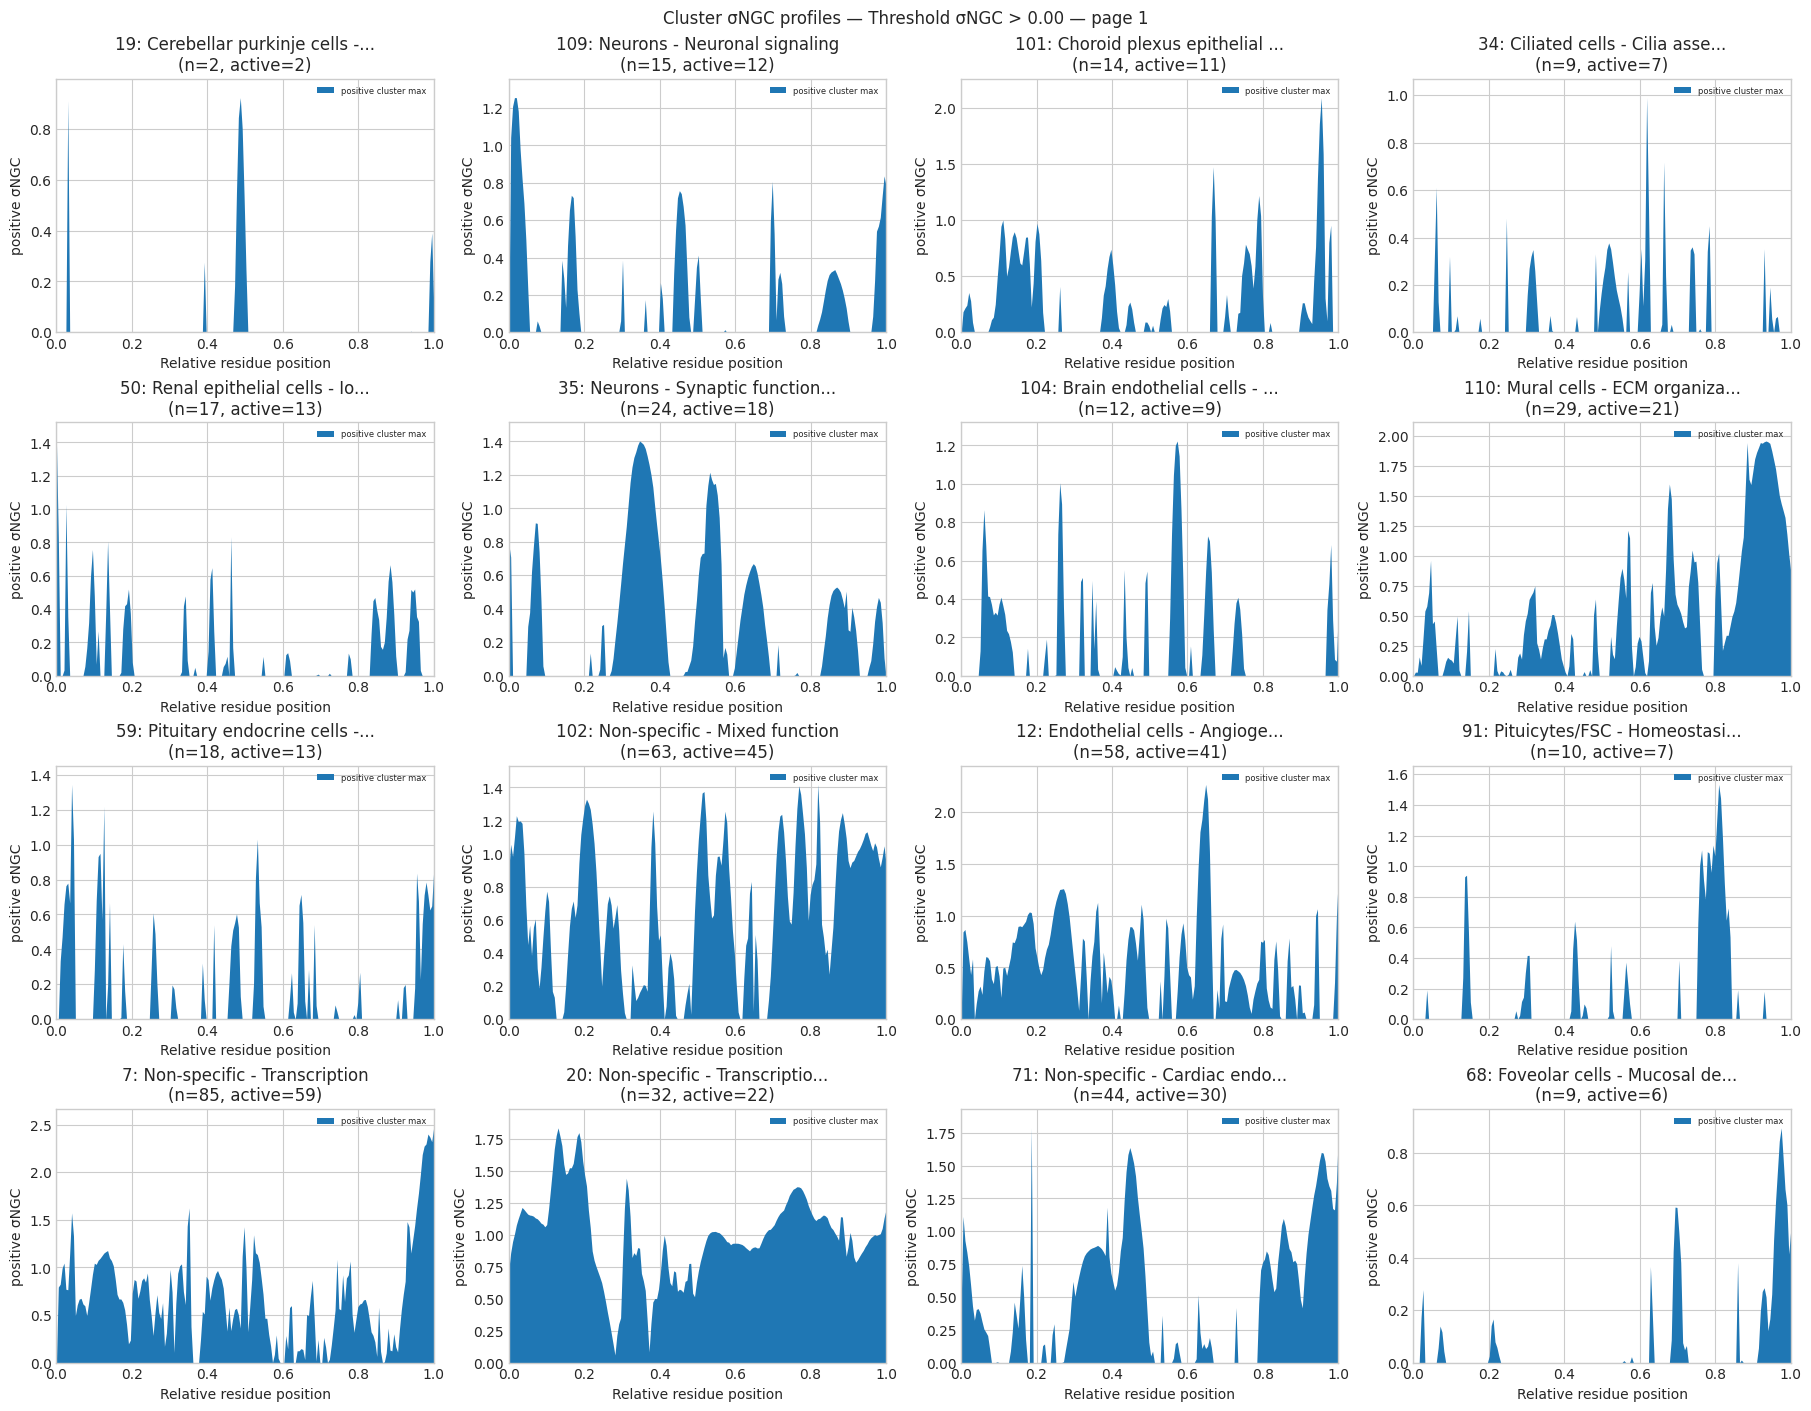

In [83]:
# graph displaying hyperplane distance sigmaNGC histogram over amino acid sequence
# there should be one graph for each unique cluster value in the csv


def positive_sigma(values: np.ndarray, fill_value: float | None = None) -> np.ndarray:
    baseline = SIGMA_ACTIVITY_THRESHOLD if fill_value is None else fill_value
    positive = np.isfinite(values) & (values > SIGMA_ACTIVITY_THRESHOLD)
    return np.where(positive, values, baseline)


def _sigma_ylim(max_sigma: np.ndarray) -> tuple[float, float]:
    positive_values = max_sigma[np.isfinite(max_sigma) & (max_sigma > SIGMA_ACTIVITY_THRESHOLD)]
    baseline = SIGMA_ACTIVITY_THRESHOLD
    hi = float(np.max(positive_values)) if positive_values.size else baseline + 0.1
    span = max(hi - baseline, 0.1)
    return (baseline, hi + 0.08 * span)


def cluster_sigma_envelope(group: ClusterGroup) -> np.ndarray:
    stacked = group.stacked_relative_sigma()
    if stacked.size == 0:
        return np.full(PROFILE_GRID, np.nan, dtype=np.float64)
    return np.nanmax(stacked, axis=0)


def shared_sigma_ylim(groups: list[ClusterGroup]) -> tuple[float, float]:
    if not groups:
        return (SIGMA_ACTIVITY_THRESHOLD, SIGMA_ACTIVITY_THRESHOLD + 0.1)
    return _sigma_ylim(np.vstack([cluster_sigma_envelope(group) for group in groups]))


def draw_sigma_histogram(
    ax,
    group: ClusterGroup,
    ylim: tuple[float, float] | None = None,
) -> None:
    x = np.linspace(0.0, 1.0, PROFILE_GRID)
    max_sigma = cluster_sigma_envelope(group)
    positive_max = positive_sigma(max_sigma)
    n_active = sum(item.statistics.s_score > 0 for item in group.profiles)

    ax.fill_between(
        x,
        SIGMA_ACTIVITY_THRESHOLD,
        positive_max,
        color="C0",
        linewidth=0,
        zorder=2,
        label="positive cluster max",
    )
    ax.axhline(SIGMA_ACTIVITY_THRESHOLD, color="black", linewidth=0.7, zorder=3)
    ax.set(
        xlim=(0.0, 1.0),
        ylim=ylim if ylim is not None else _sigma_ylim(max_sigma),
        xlabel="Relative residue position",
        ylabel="positive σNGC",
        title=f"{short_cluster_label(group.name, 34)}\n(n={group.n}, active={n_active})",
    )
    ax.legend(fontsize=6, loc="upper right")


def preview_groups(groups: list[ClusterGroup]) -> list[ClusterGroup]:
    if PLOT_PREVIEW_LIMIT is None:
        return groups
    return groups[: max(0, int(PLOT_PREVIEW_LIMIT))]


def prepare_plot_style_dir(plot_style: str) -> Path:
    save_dir = CLUSTER_PLOT_DIR / plot_style
    save_dir.mkdir(parents=True, exist_ok=True)
    for stale in save_dir.glob("page_*.png"):
        stale.unlink()
    return save_dir


def render_cluster_figure(batch: list[ClusterGroup], draw, suptitle: str, page: int):
    fig, axes = plt.subplots(
        PLOT_GRID_ROWS,
        PLOT_GRID_COLUMNS,
        figsize=(18.0, 14.0),
        layout="constrained",
    )
    flat_axes = axes.ravel()
    for ax, group in zip(flat_axes, batch):
        draw(ax, group)
    for ax in flat_axes[len(batch) :]:
        ax.set_visible(False)
    fig.suptitle(f"{suptitle} — {activity_boundary_label()} — page {page}")
    return fig


def plot_cluster_pages(
    groups: list[ClusterGroup],
    draw,
    *,
    plot_style: str,
    suptitle: str,
    description: str,
) -> None:
    page_size = PLOT_GRID_ROWS * PLOT_GRID_COLUMNS
    display_groups = preview_groups(groups)
    render_groups = groups if SAVE_ALL_CLUSTER_PLOTS else display_groups
    save_dir = prepare_plot_style_dir(plot_style) if SAVE_ALL_CLUSTER_PLOTS else None
    n_pages = (len(render_groups) + page_size - 1) // page_size if render_groups else 0
    print(f"Plotting {len(display_groups)} of {len(groups)} {description}.")
    if save_dir is not None:
        print(f"Saving {len(render_groups)} cluster(s) as {n_pages} 4x4 page(s) to {save_dir}")

    for page, start in enumerate(range(0, len(render_groups), page_size), start=1):
        batch = render_groups[start : start + page_size]
        fig = render_cluster_figure(batch, draw, suptitle, page)
        if save_dir is not None:
            fig.savefig(save_dir / f"page_{page:02d}.png", dpi=SAVE_DPI, bbox_inches="tight")
        if start < len(display_groups):
            plt.show()
        else:
            plt.close(fig)


def plot_sigma_by_cluster(groups: list[ClusterGroup]) -> None:
    ylim = shared_sigma_ylim(groups) if SCALE_HISTOGRAM_Y else None

    def draw(ax, group: ClusterGroup) -> None:
        draw_sigma_histogram(ax, group, ylim=ylim)

    plot_cluster_pages(
        groups,
        draw,
        plot_style="sigma_ngc",
        suptitle="Cluster σNGC profiles",
        description="cluster σ profiles",
    )


plot_sigma_by_cluster(clusters)


Plotting 16 of 110 DNGC distributions.
Saving 110 cluster(s) as 7 4x4 page(s) to /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/data/skin_samples/results/dngc_cluster_plots/dngc


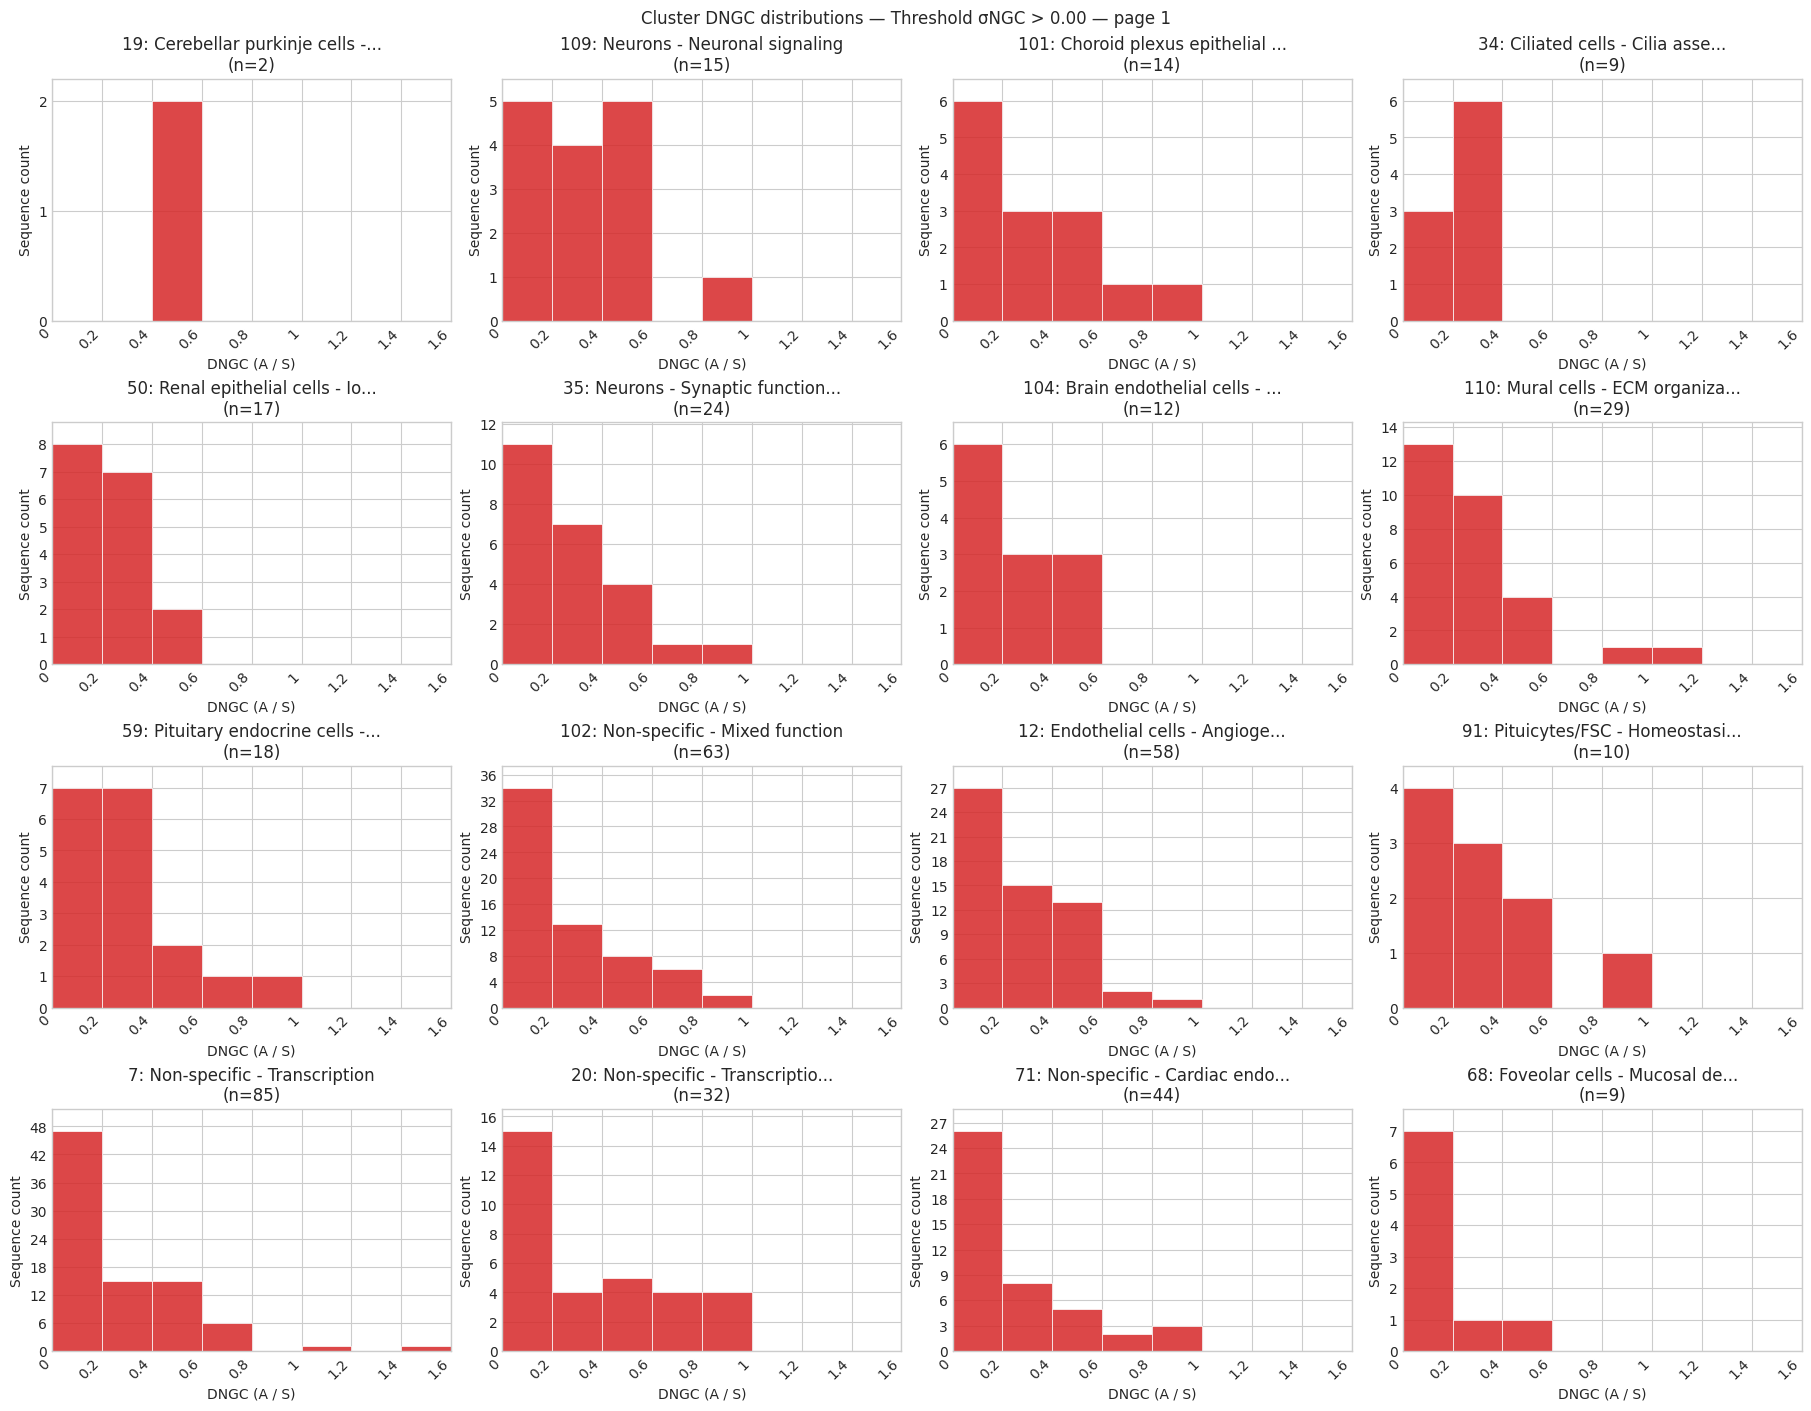

In [84]:
def _nice_bin_width(span: float, target_bins: int = 12) -> float:
    raw = span / max(target_bins, 1)
    if raw <= 0:
        return 1.0
    exponent = np.floor(np.log10(raw))
    fraction = raw / (10 ** exponent)
    if fraction <= 1:
        nice = 1.0
    elif fraction <= 2:
        nice = 2.0
    elif fraction <= 5:
        nice = 5.0
    else:
        nice = 10.0
    return float(nice * (10 ** exponent))


def histogram_bins(values: np.ndarray, target_bins: int = 12) -> np.ndarray:
    finite = values[np.isfinite(values)]
    maximum = float(finite.max()) if finite.size else 0.0
    width = _nice_bin_width(max(maximum, 0.0), target_bins)
    data_upper = max(width, float(np.ceil(maximum / width) * width)) if width else 1.0
    return np.arange(0.0, data_upper + width, width)


def configure_histogram_x_axis(ax, bins: np.ndarray, max_labels: int | None = None) -> None:
    ax.set_xticks(bins)
    ax.set_xticklabels([f"{edge:g}" for edge in bins])
    if len(bins) > 8:
        ax.tick_params(axis="x", labelrotation=45)
        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")

def histogram_peak_count(values: np.ndarray, bins: np.ndarray) -> float:
    finite = np.asarray(values, dtype=np.float64)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return 0.0
    counts, _ = np.histogram(finite, bins=bins)
    return float(counts.max()) if counts.size else 0.0


def shared_histogram_ylim(value_arrays: list[np.ndarray], bins: np.ndarray) -> tuple[float, float]:
    peak = 0.0
    for values in value_arrays:
        peak = max(peak, histogram_peak_count(values, bins))
    hi = max(peak, 1.0)
    return (0.0, hi * 1.1)


def draw_distribution(
    ax,
    values: np.ndarray,
    bins: np.ndarray,
    title: str,
    xlabel: str,
    color: str,
    all_zero_message: str | None = None,
    ylim: tuple[float, float] | None = None,
) -> None:
    finite = values[np.isfinite(values)]
    ax.hist(
        finite,
        bins=bins,
        color=color,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.6,
    )
    if all_zero_message and finite.size and np.allclose(finite, 0.0):
        ax.text(
            0.5,
            0.88,
            all_zero_message.format(count=finite.size),
            ha="center",
            transform=ax.transAxes,
            fontsize=8,
        )
    ax.set(
        xlim=(float(bins[0]), float(bins[-1])),
        xlabel=xlabel,
        ylabel="Sequence count",
        title=title,
    )
    configure_histogram_x_axis(ax, bins)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    if ylim is None:
        ax.margins(y=0.1)
    else:
        ax.set_ylim(ylim)


def concatenated_metric_values(groups: list[ClusterGroup], values_from_group) -> np.ndarray:
    if not groups:
        return np.empty(0, dtype=np.float64)
    return np.concatenate(
        [np.asarray(values_from_group(group), dtype=np.float64) for group in groups]
    )


def make_cluster_distribution_draw(
    values_from_group,
    xlabel: str,
    all_zero_message: str,
    groups: list[ClusterGroup],
):
    arrays = [np.asarray(values_from_group(group), dtype=np.float64) for group in groups]
    bins = histogram_bins(
        np.concatenate(arrays) if arrays else np.empty(0, dtype=np.float64)
    )
    ylim = shared_histogram_ylim(arrays, bins) if SCALE_HISTOGRAM_Y else None

    def draw(ax, group: ClusterGroup) -> None:
        draw_distribution(
            ax,
            np.asarray(values_from_group(group), dtype=np.float64),
            bins,
            f"{short_cluster_label(group.name, 34)}\n(n={group.n})",
            xlabel,
            "C3",
            all_zero_message,
            ylim=ylim,
        )

    return draw


def cluster_dngc_values(group: ClusterGroup) -> np.ndarray:
    return np.asarray(
        [item.statistics.dngc for item in group.profiles],
        dtype=np.float64,
    )


def plot_cluster_dngc_distributions(groups: list[ClusterGroup]) -> None:
    plot_cluster_pages(
        groups,
        make_cluster_distribution_draw(
            cluster_dngc_values,
            "DNGC (A / S)",
            "All {count} sequences have DNGC = 0",
            groups,
        ),
        plot_style="dngc",
        suptitle="Cluster DNGC distributions",
        description="DNGC distributions",
    )


plot_cluster_dngc_distributions(clusters)


Plotting 16 of 110 S distributions.
Saving 110 cluster(s) as 7 4x4 page(s) to /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/data/skin_samples/results/dngc_cluster_plots/s


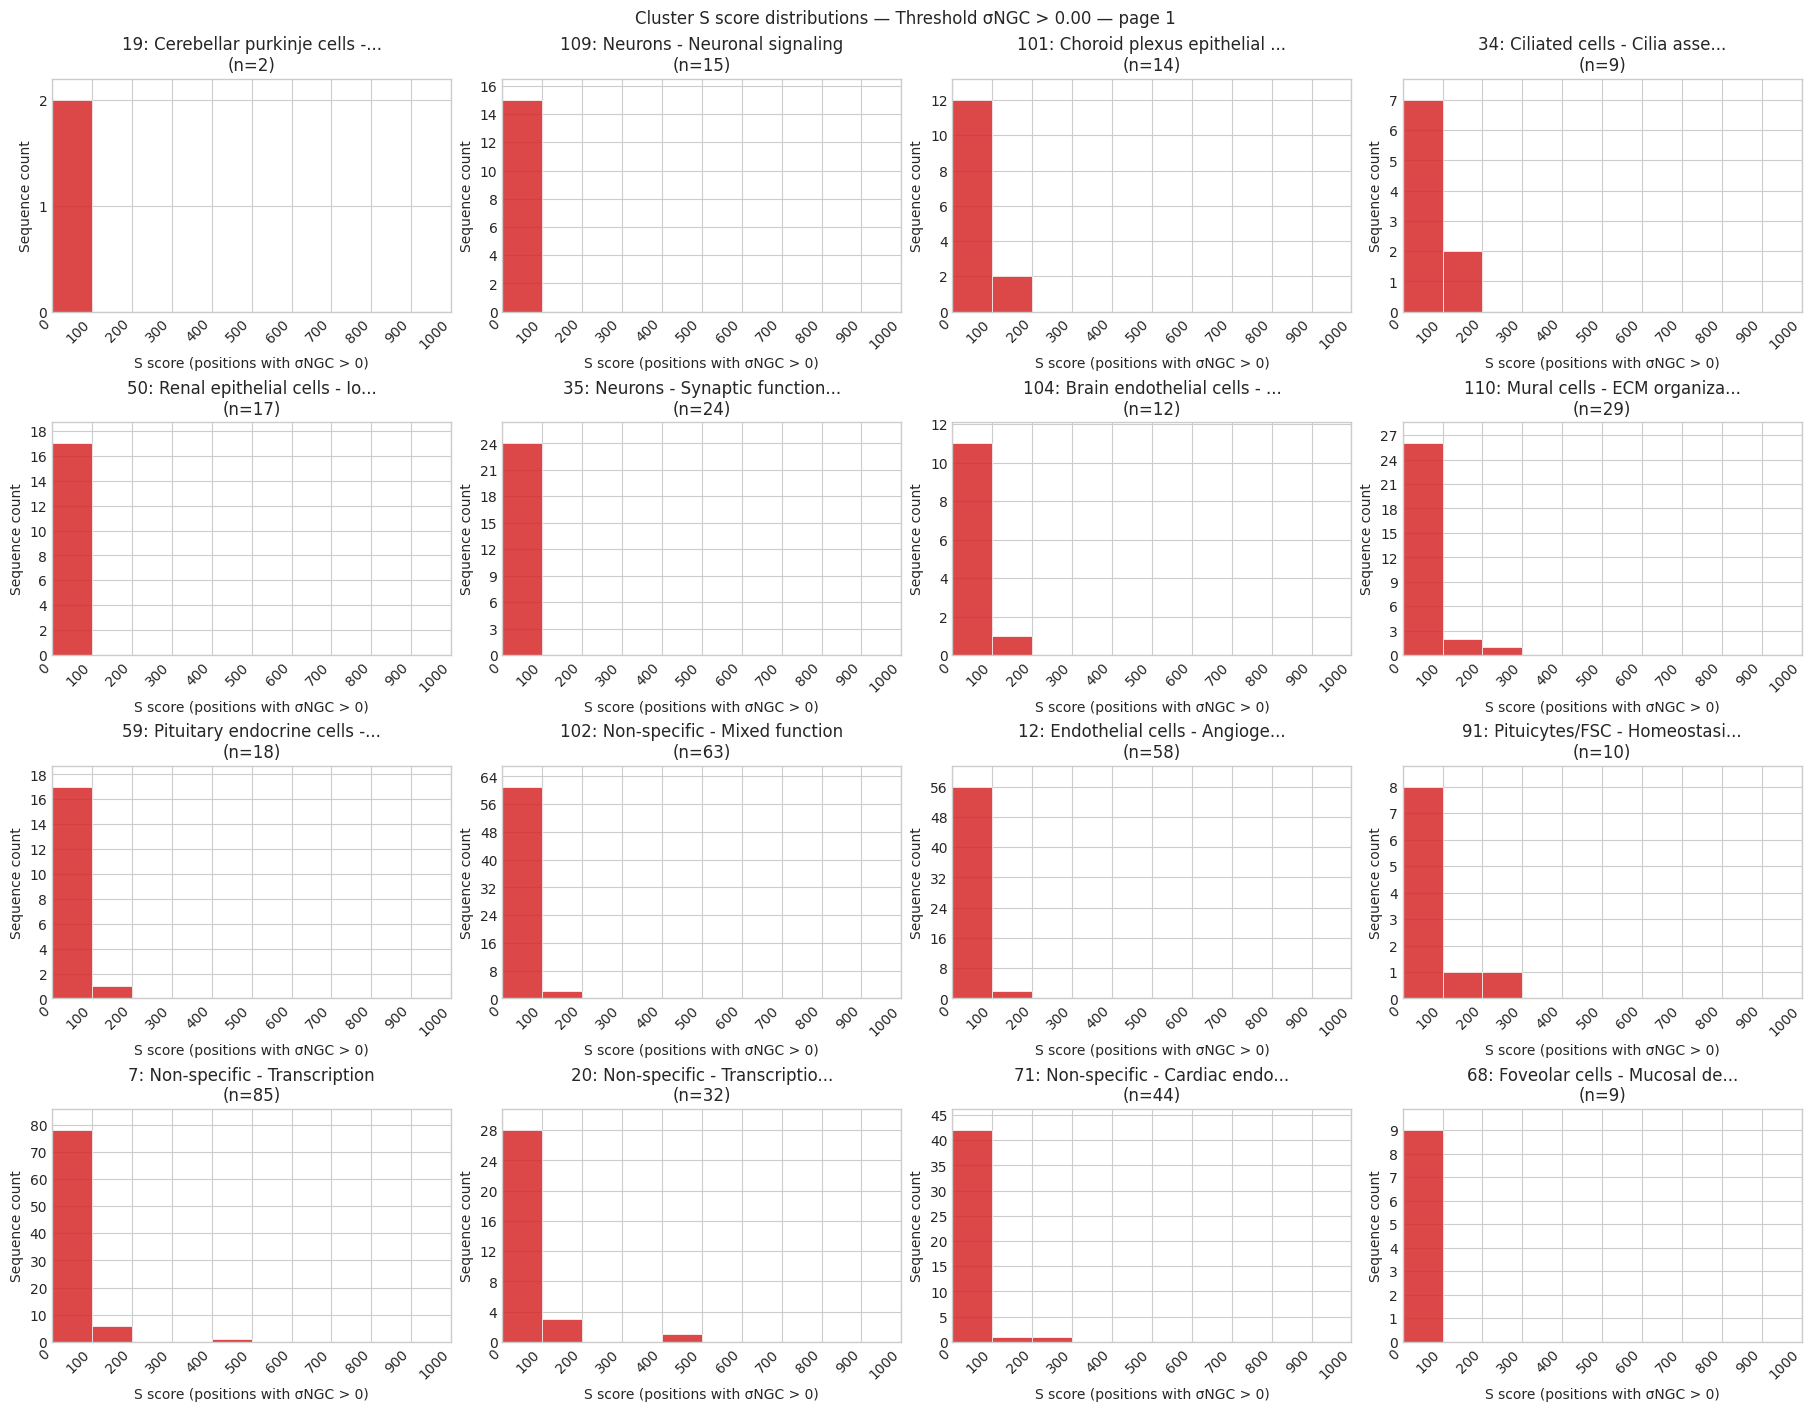

In [85]:
def sequence_s_score_values(group: ClusterGroup) -> np.ndarray:
    return np.asarray(
        [item.statistics.s_score for item in group.profiles],
        dtype=np.float64,
    )


def plot_cluster_s_score_distributions(groups: list[ClusterGroup]) -> None:
    plot_cluster_pages(
        groups,
        make_cluster_distribution_draw(
            sequence_s_score_values,
            "S score (positions with σNGC > 0)",
            "All {count} sequences have S = 0",
            groups,
        ),
        plot_style="s",
        suptitle="Cluster S score distributions",
        description="S distributions",
    )


plot_cluster_s_score_distributions(clusters)


Plotting 16 of 110 A distributions.
Saving 110 cluster(s) as 7 4x4 page(s) to /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/data/skin_samples/results/dngc_cluster_plots/a


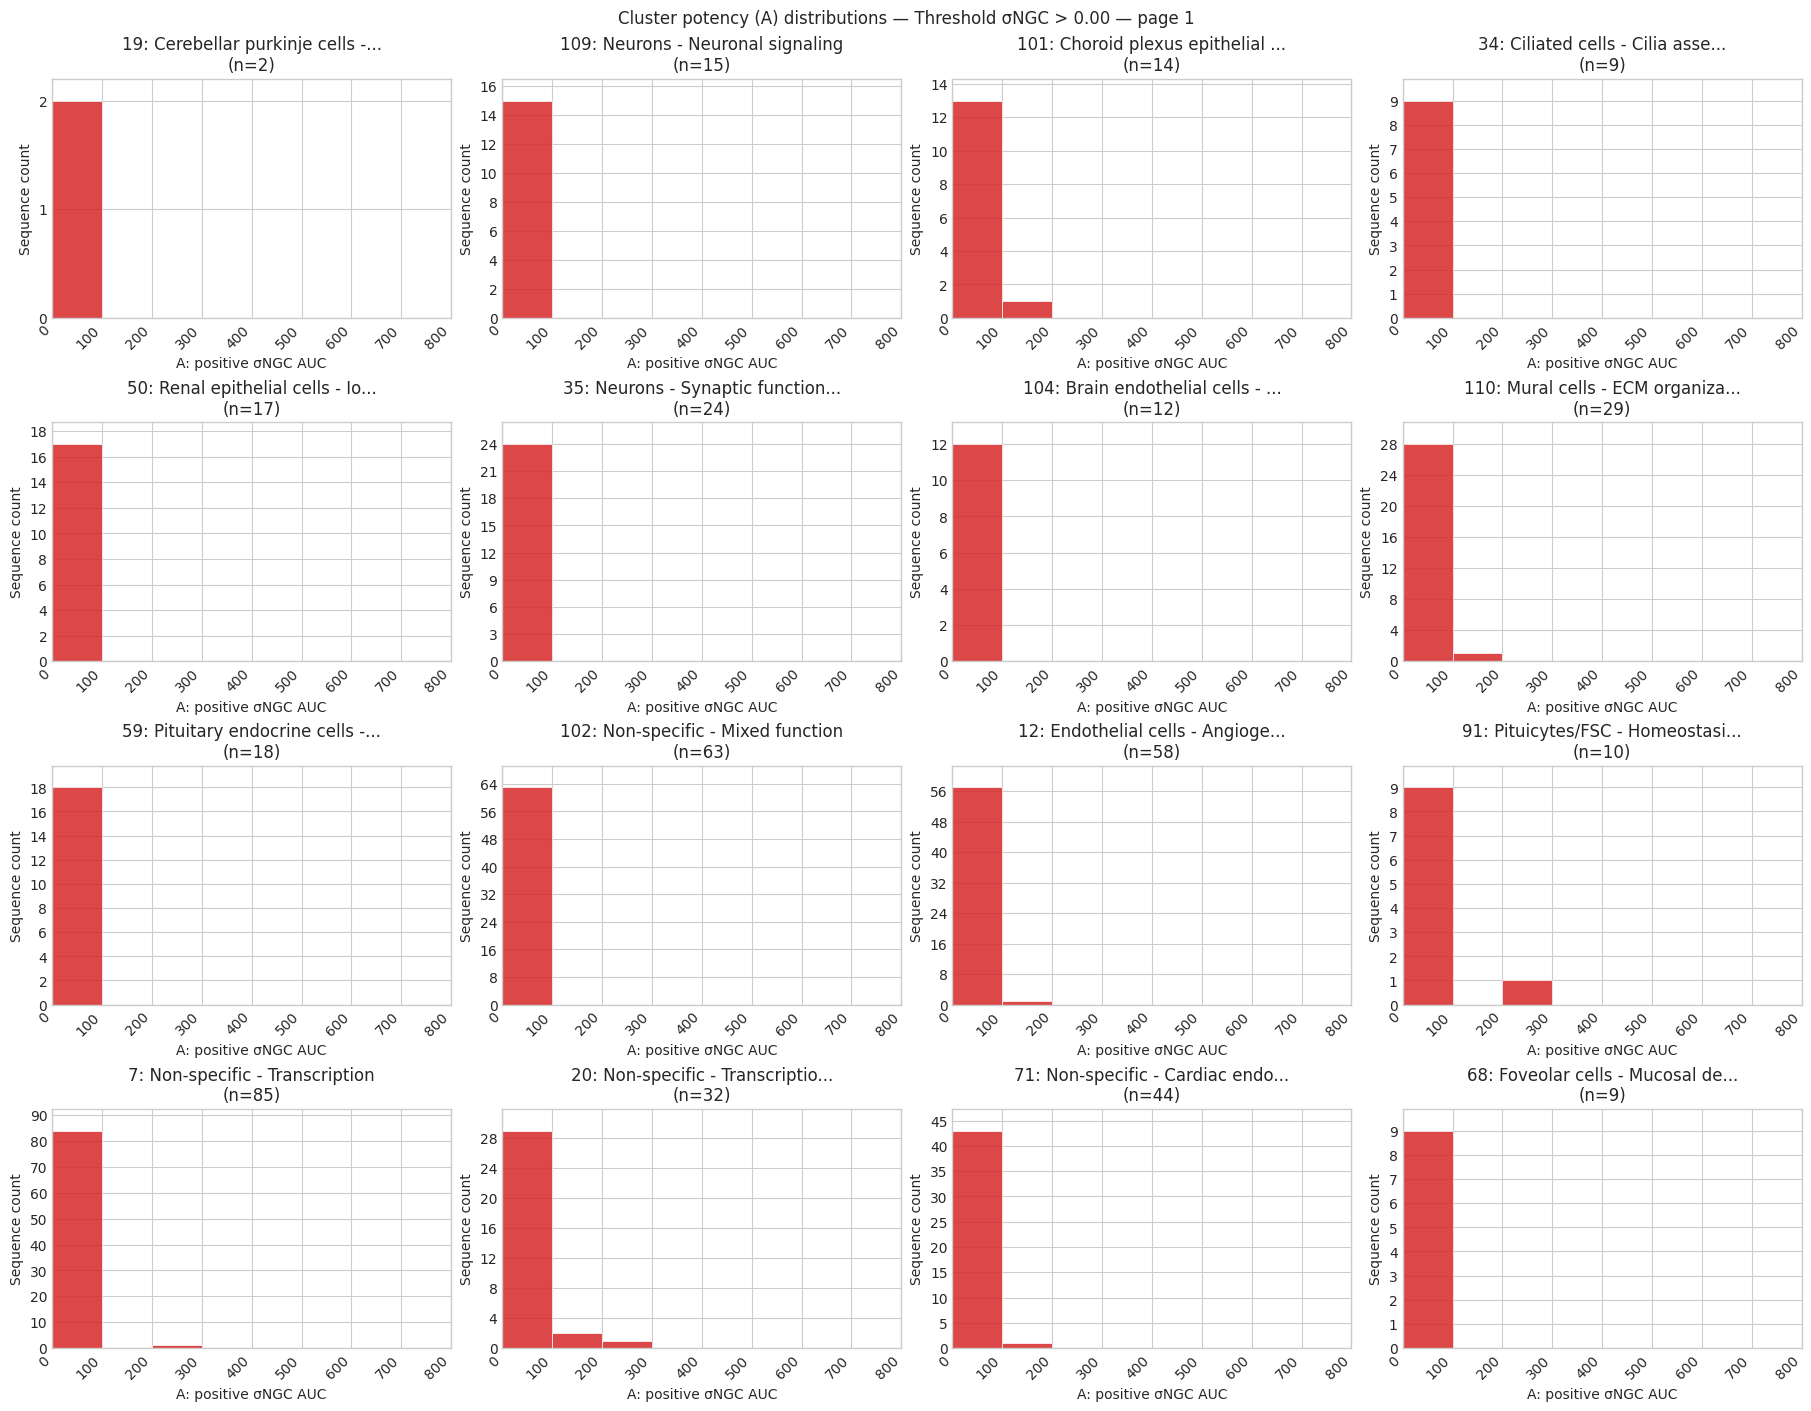

In [86]:
def sequence_a_values(group: ClusterGroup) -> np.ndarray:
    return np.asarray(
        [item.statistics.potency_auc for item in group.profiles],
        dtype=np.float64,
    )


def plot_cluster_a_distributions(groups: list[ClusterGroup]) -> None:
    plot_cluster_pages(
        groups,
        make_cluster_distribution_draw(
            sequence_a_values,
            "A: positive σNGC AUC",
            "All {count} sequences have A = 0",
            groups,
        ),
        plot_style="a",
        suptitle="Cluster potency (A) distributions",
        description="A distributions",
    )


plot_cluster_a_distributions(clusters)

Plotting 16 of 110 F distributions.
Saving 110 cluster(s) as 7 4x4 page(s) to /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/data/skin_samples/results/dngc_cluster_plots/f


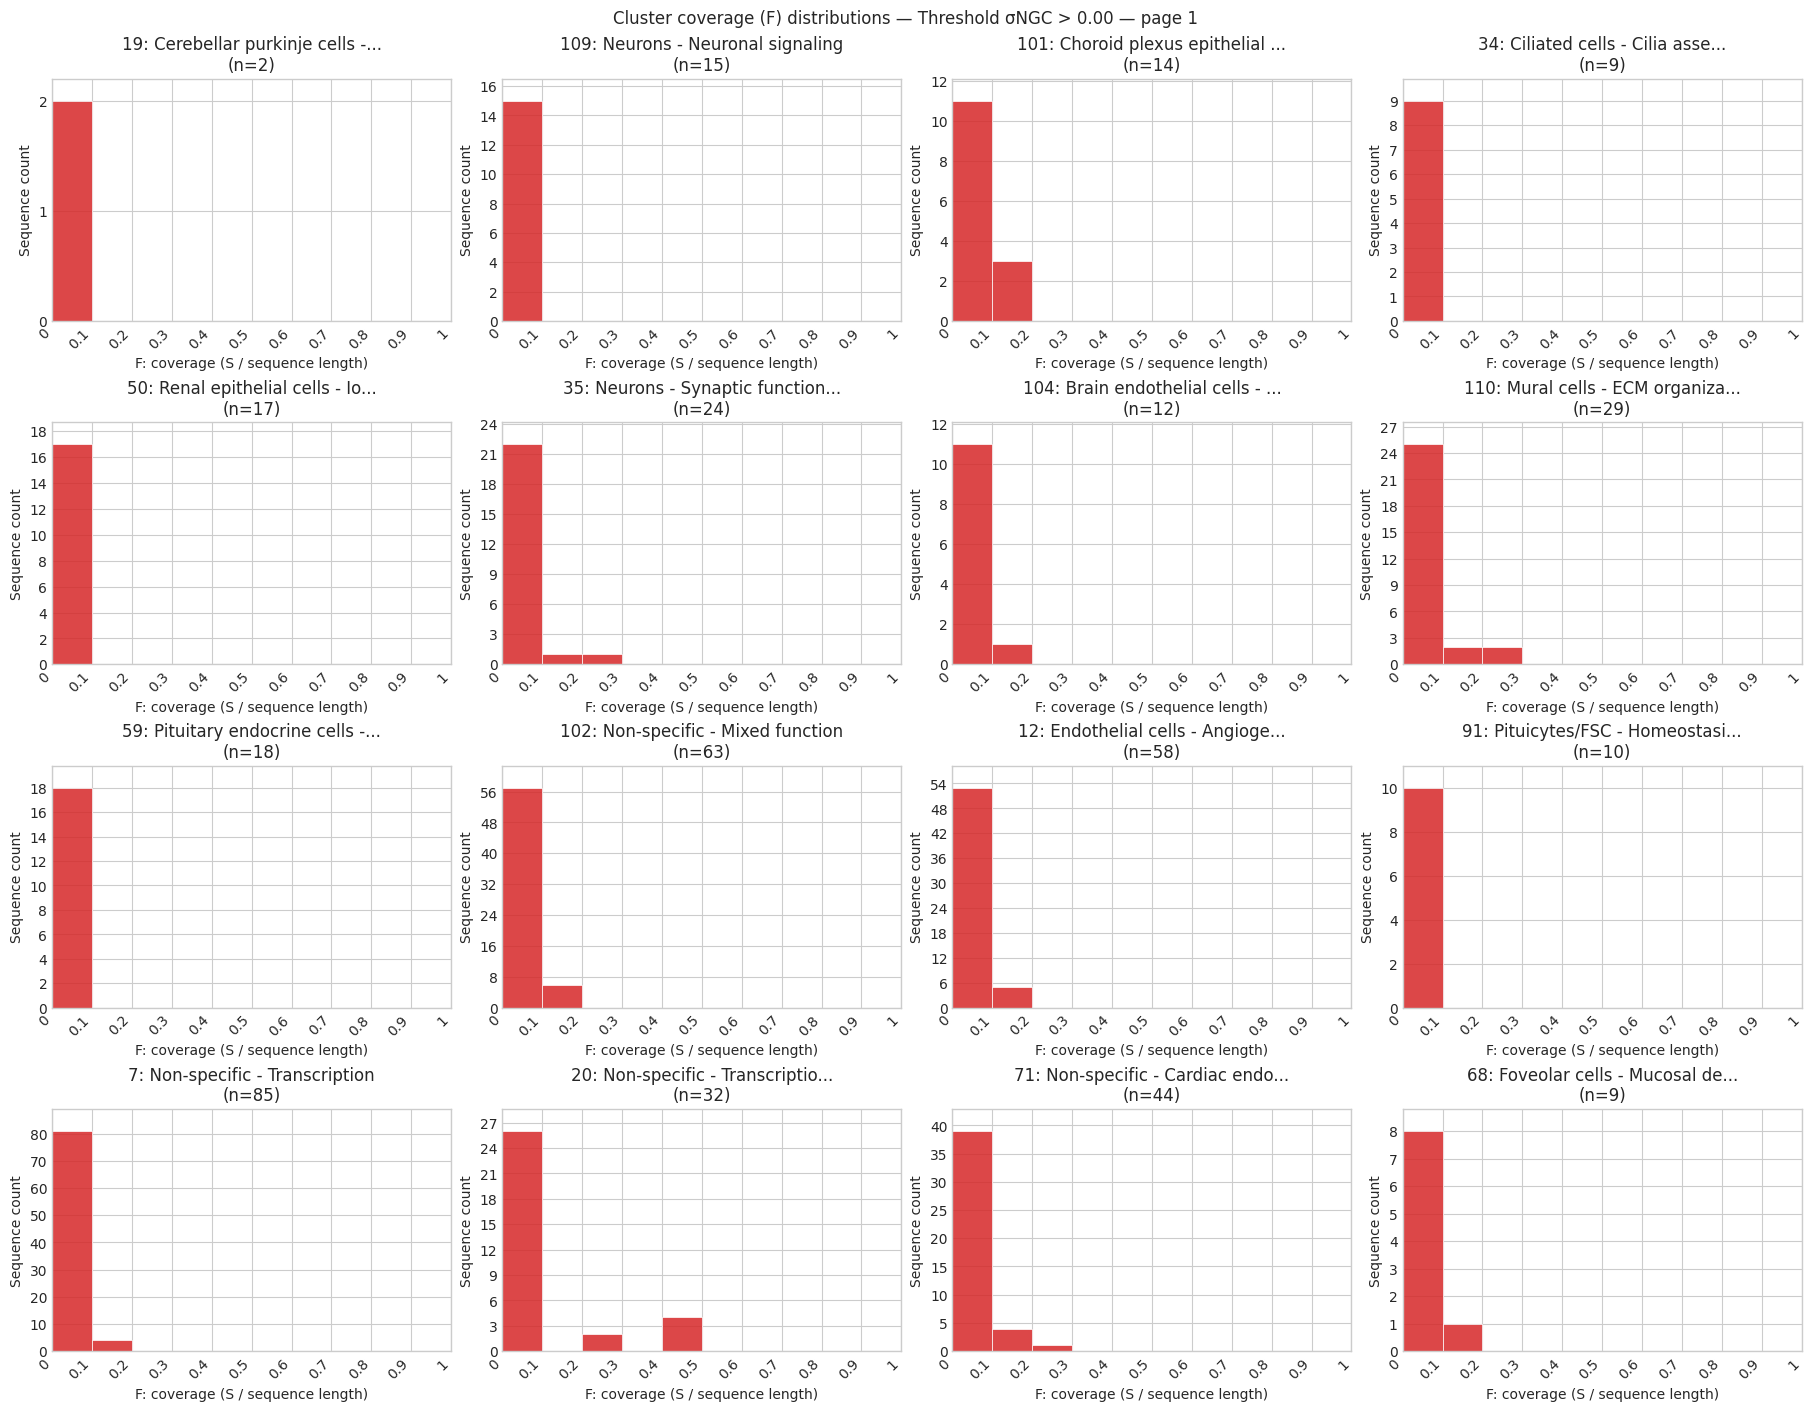

In [87]:
def sequence_f_values(group: ClusterGroup) -> np.ndarray:
    return np.asarray(
        [item.statistics.coverage for item in group.profiles],
        dtype=np.float64,
    )


def plot_cluster_f_distributions(groups: list[ClusterGroup]) -> None:
    plot_cluster_pages(
        groups,
        make_cluster_distribution_draw(
            sequence_f_values,
            "F: coverage (S / sequence length)",
            "All {count} sequences have F = 0",
            groups,
        ),
        plot_style="f",
        suptitle="Cluster coverage (F) distributions",
        description="F distributions",
    )


plot_cluster_f_distributions(clusters)


Plotting fragment tracks for 16 of 110 clusters.
Saving 110 cluster track(s) as 7 page(s) to /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/data/skin_samples/results/dngc_cluster_plots/n


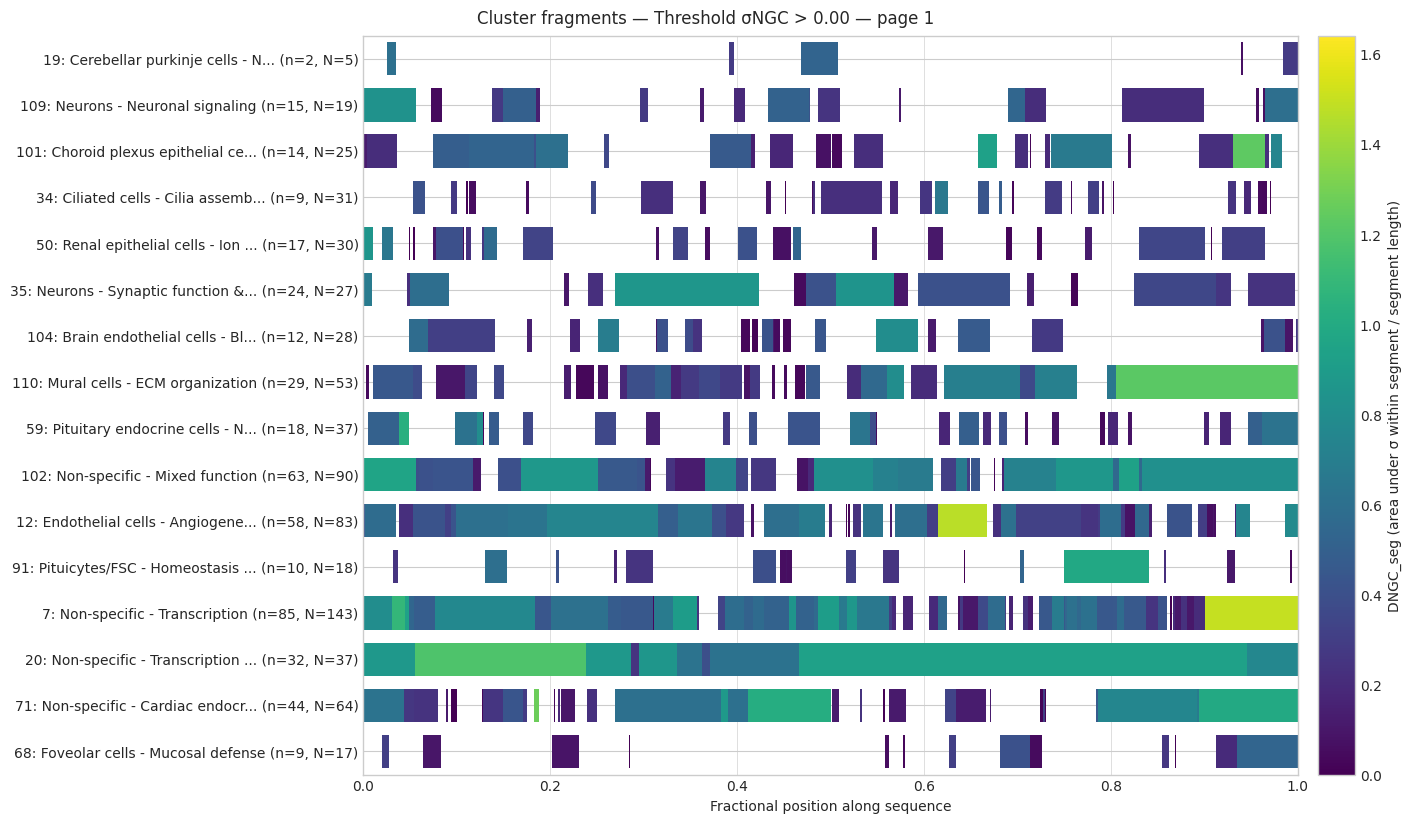

In [88]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

FRAGMENT_ROWS_PER_PAGE = 16


def active_fragment_spans(sigma: np.ndarray, p_amp: np.ndarray) -> list[tuple[int, int, float]]:
    active = activity_mask(sigma, p_amp)
    if active.size == 0 or not np.any(active):
        return []
    padded = np.concatenate([[False], active, [False]])
    changes = np.diff(padded.astype(np.int8))
    starts = np.flatnonzero(changes == 1)
    ends = np.flatnonzero(changes == -1)
    spans = []
    for start, end in zip(starts, ends):
        segment = sigma[start:end]
        spans.append((int(start), int(end), float(np.sum(segment) / segment.size)))
    return spans


def cluster_fragment_tracks(group: ClusterGroup) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    starts: list[float] = []
    widths: list[float] = []
    scores: list[float] = []
    for item in group.profiles:
        length = item.sequence_length
        if length <= 0:
            continue
        for start, end, dngc in active_fragment_spans(item.sigma, item.p_amp):
            starts.append(start / length)
            widths.append((end - start) / length)
            scores.append(dngc)
    return (
        np.asarray(starts, dtype=np.float64),
        np.asarray(widths, dtype=np.float64),
        np.asarray(scores, dtype=np.float64),
    )


def fragment_dngc_vmax(groups: list[ClusterGroup]) -> float:
    peak = 0.0
    for group in groups:
        scores = cluster_fragment_tracks(group)[2]
        if scores.size:
            peak = max(peak, float(np.max(scores)))
    return peak if peak > 0.0 else 1.0


def draw_fragment_tracks(ax, groups: list[ClusterGroup], norm: Normalize) -> None:
    cmap = plt.get_cmap("viridis")
    labels = []
    for row, group in enumerate(groups):
        starts, widths, scores = cluster_fragment_tracks(group)
        order = np.argsort(scores) if scores.size else np.empty(0, dtype=int)
        for index in order:
            ax.barh(
                row,
                widths[index],
                left=starts[index],
                height=0.72,
                color=cmap(norm(scores[index])),
                linewidth=0,
                zorder=2,
            )
        labels.append(f"{short_cluster_label(group.name, 36)} (n={group.n}, N={scores.size})")
    ax.set_yticks(np.arange(len(groups)))
    ax.set_yticklabels(labels)
    ax.set_ylim(len(groups) - 0.5, -0.5)
    ax.set_xlim(0.0, 1.0)
    ax.set_xlabel("Fractional position along sequence")
    ax.grid(axis="x", color="0.85", linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)


def plot_cluster_fragment_tracks(groups: list[ClusterGroup]) -> None:
    if not groups:
        print("No clusters to plot.")
        return
    norm = Normalize(vmin=0.0, vmax=fragment_dngc_vmax(groups))
    page_size = FRAGMENT_ROWS_PER_PAGE
    display_count = len(preview_groups(groups))
    render_groups = groups if SAVE_ALL_CLUSTER_PLOTS else preview_groups(groups)
    save_dir = prepare_plot_style_dir("n") if SAVE_ALL_CLUSTER_PLOTS else None
    n_pages = (len(render_groups) + page_size - 1) // page_size
    print(f"Plotting fragment tracks for {display_count} of {len(groups)} clusters.")
    if save_dir is not None:
        print(f"Saving {len(render_groups)} cluster track(s) as {n_pages} page(s) to {save_dir}")

    for page, start in enumerate(range(0, len(render_groups), page_size), start=1):
        batch = render_groups[start : start + page_size]
        fig, ax = plt.subplots(
            figsize=(14.0, max(3.2, 0.42 * len(batch) + 1.4)),
            layout="constrained",
        )
        draw_fragment_tracks(ax, batch, norm)
        fig.colorbar(
            ScalarMappable(norm=norm, cmap="viridis"),
            ax=ax,
            pad=0.01,
            label="DNGC_seg (area under σ within segment / segment length)",
        )
        fig.suptitle(f"Cluster fragments — {activity_boundary_label()} — page {page}")
        if save_dir is not None:
            fig.savefig(save_dir / f"page_{page:02d}.png", dpi=SAVE_DPI, bbox_inches="tight")
        if start < display_count:
            plt.show()
        else:
            plt.close(fig)


plot_cluster_fragment_tracks(clusters)


In [89]:
def total_fragment_count(group: ClusterGroup) -> int:
    return int(sum(item.statistics.fragment_count for item in group.profiles))


def fragment_count_table(groups: list[ClusterGroup]) -> pd.DataFrame:
    table = pd.DataFrame(
        {
            CLUSTER_COL: [group.name for group in groups],
            "protein_count": [group.n for group in groups],
            "fragment_count": [total_fragment_count(group) for group in groups],
        }
    )
    return table.sort_values(
        "fragment_count",
        ascending=False,
        kind="mergesort",
        ignore_index=True,
    )


all_fragment_counts = fragment_count_table(
    build_cluster_groups(
        profiles_df,
        sigma_profile_column,
        p_amp_profile_column,
        limit=None,
    )
)
top_fragment_clusters = all_fragment_counts.head(5).copy()
top_fragment_clusters.insert(0, "rank", range(1, len(top_fragment_clusters) + 1))
no_fragment_clusters = (
    all_fragment_counts.loc[all_fragment_counts["fragment_count"] == 0]
    .sort_values(CLUSTER_COL, key=lambda names: names.map(cluster_sort_key))
    .reset_index(drop=True)
)

print(f"Top {len(top_fragment_clusters)} clusters by fragment count:")
with pd.option_context("display.max_colwidth", None):
    display(top_fragment_clusters)
print(f"Clusters with no fragments: {len(no_fragment_clusters)}")
with pd.option_context("display.max_colwidth", None):
    display(no_fragment_clusters)


Top 5 clusters by fragment count:


,rank,single_cell_expression_cluster,protein_count,fragment_count
0,1,Cluster 17: Non-specific - RNA processing,200,238
1,2,Cluster 108: Fibroblasts - ECM organization,166,200
2,3,Cluster 15: Non-specific - Protein processing,138,173
3,4,Cluster 7: Non-specific - Transcription,85,143
4,5,Cluster 24: Neutrophils - Innate immunity signal integration,90,138


Clusters with no fragments: 1


,single_cell_expression_cluster,protein_count,fragment_count
0,Cluster 95: Tuft cells - Chemosensory signaling,2,0


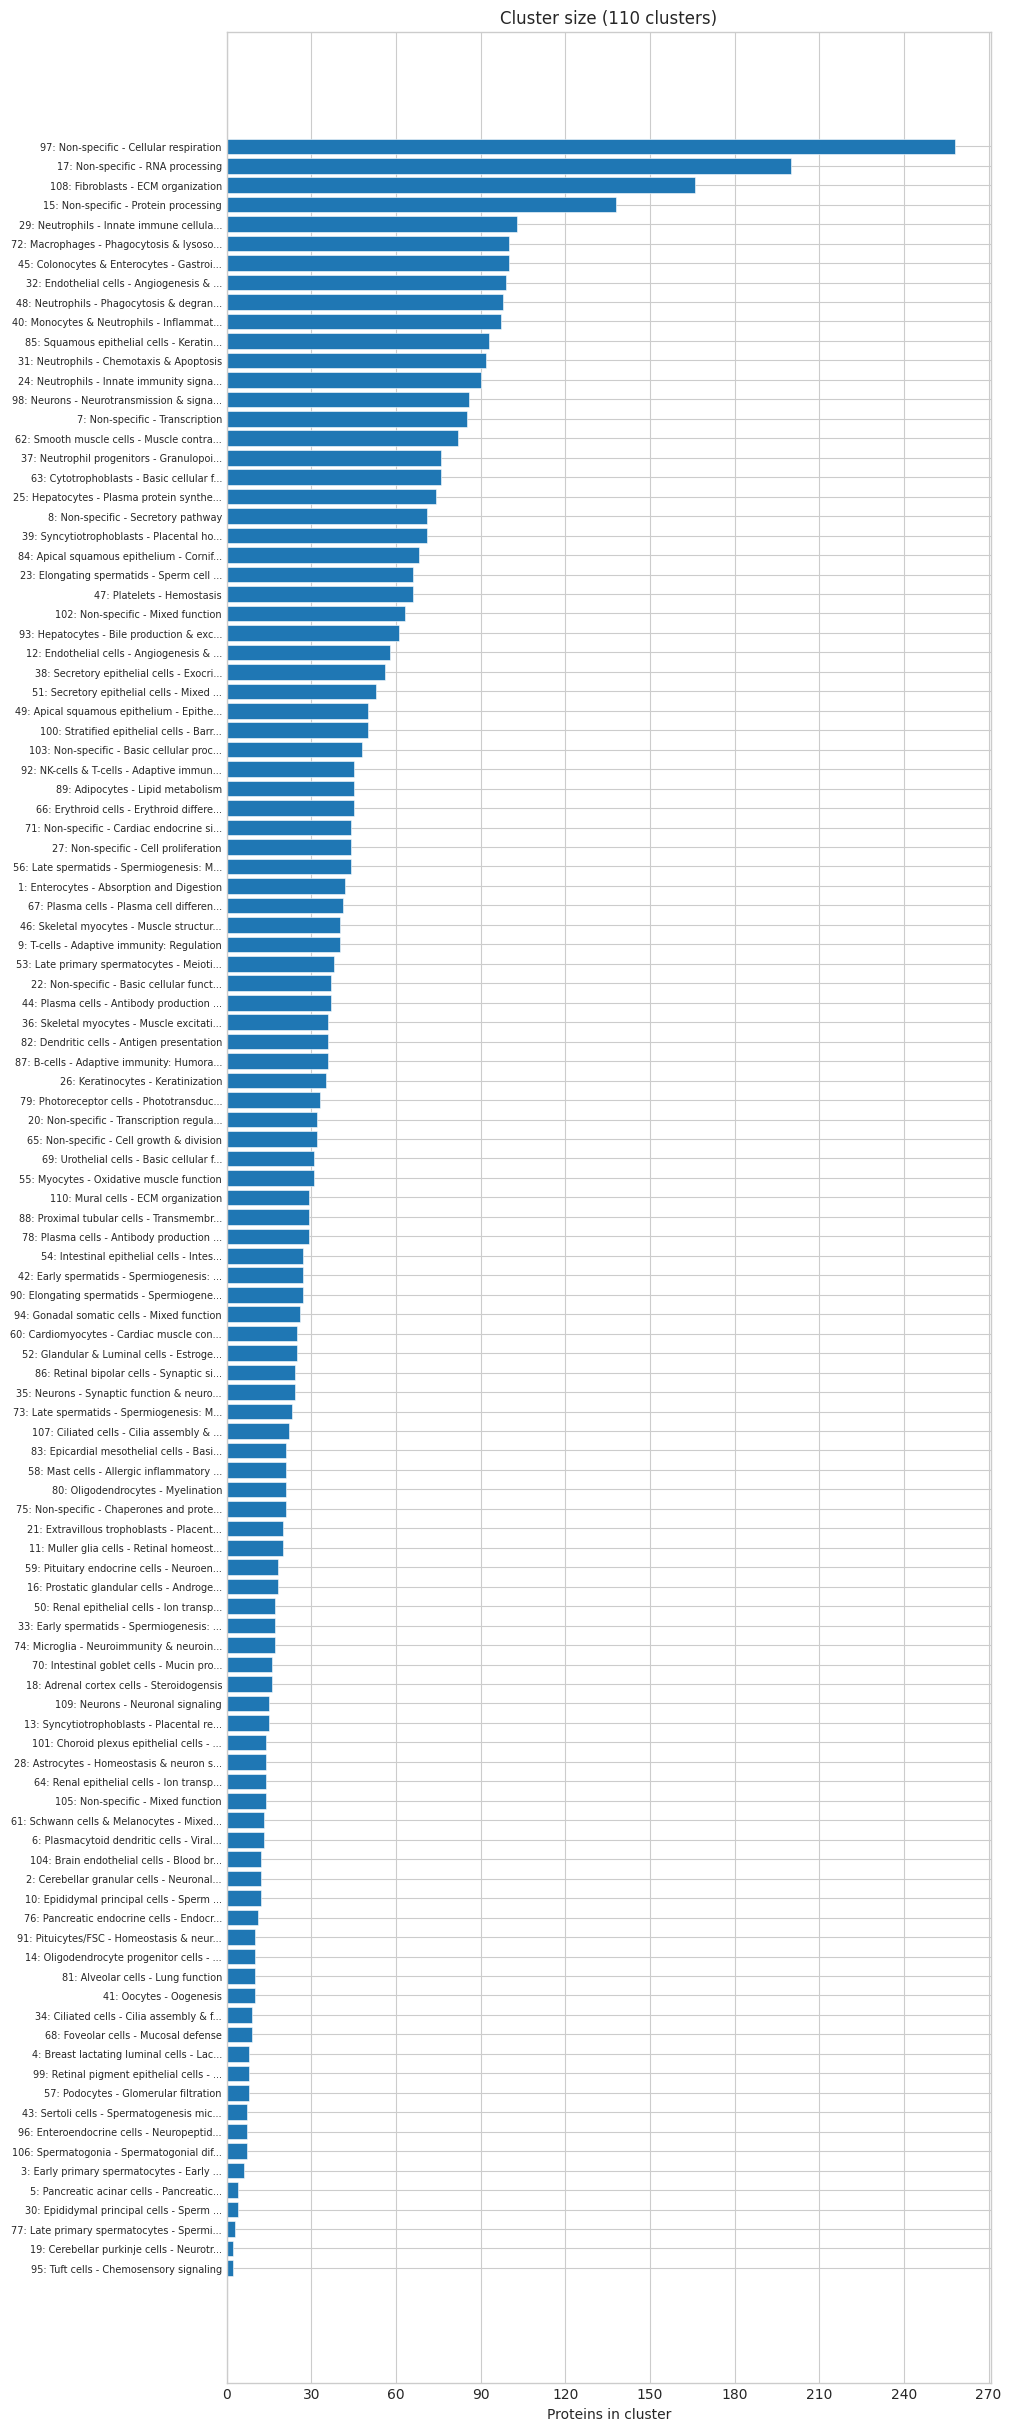

In [90]:
def plot_cluster_size_counts(table: pd.DataFrame) -> None:
    ordered = table.sort_values("protein_count", ascending=False, kind="mergesort")
    labels = [short_cluster_label(name, 42) for name in ordered[CLUSTER_COL]]
    values = ordered["protein_count"].to_numpy()
    y = np.arange(len(ordered))
    fig, ax = plt.subplots(
        figsize=(10.0, max(4.5, 0.22 * max(len(ordered), 1))),
        layout="constrained",
    )
    ax.barh(y, values, color="C0", edgecolor="white", linewidth=0.4)
    ax.set_yticks(y, labels)
    ax.invert_yaxis()
    ax.set_xlabel("Proteins in cluster")
    ax.set_title(f"Cluster size ({len(ordered)} clusters)")
    ax.tick_params(axis="y", labelsize=7)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.show()


plot_cluster_size_counts(all_fragment_counts)


## Prevalence within cluster

Fraction of proteins in each cluster with at least one residue above the σNGC boundary. That boundary is sigma = 0 unless `P_AMP_FITTING` is set, in which case it is the SVM sigma whose calibrated P(AMP) equals that value. One plot uses the mean window profile; the other uses the max window profile. Clusters are in the same order in both figures (mean fragment count, descending).


Prevalence for 110 clusters


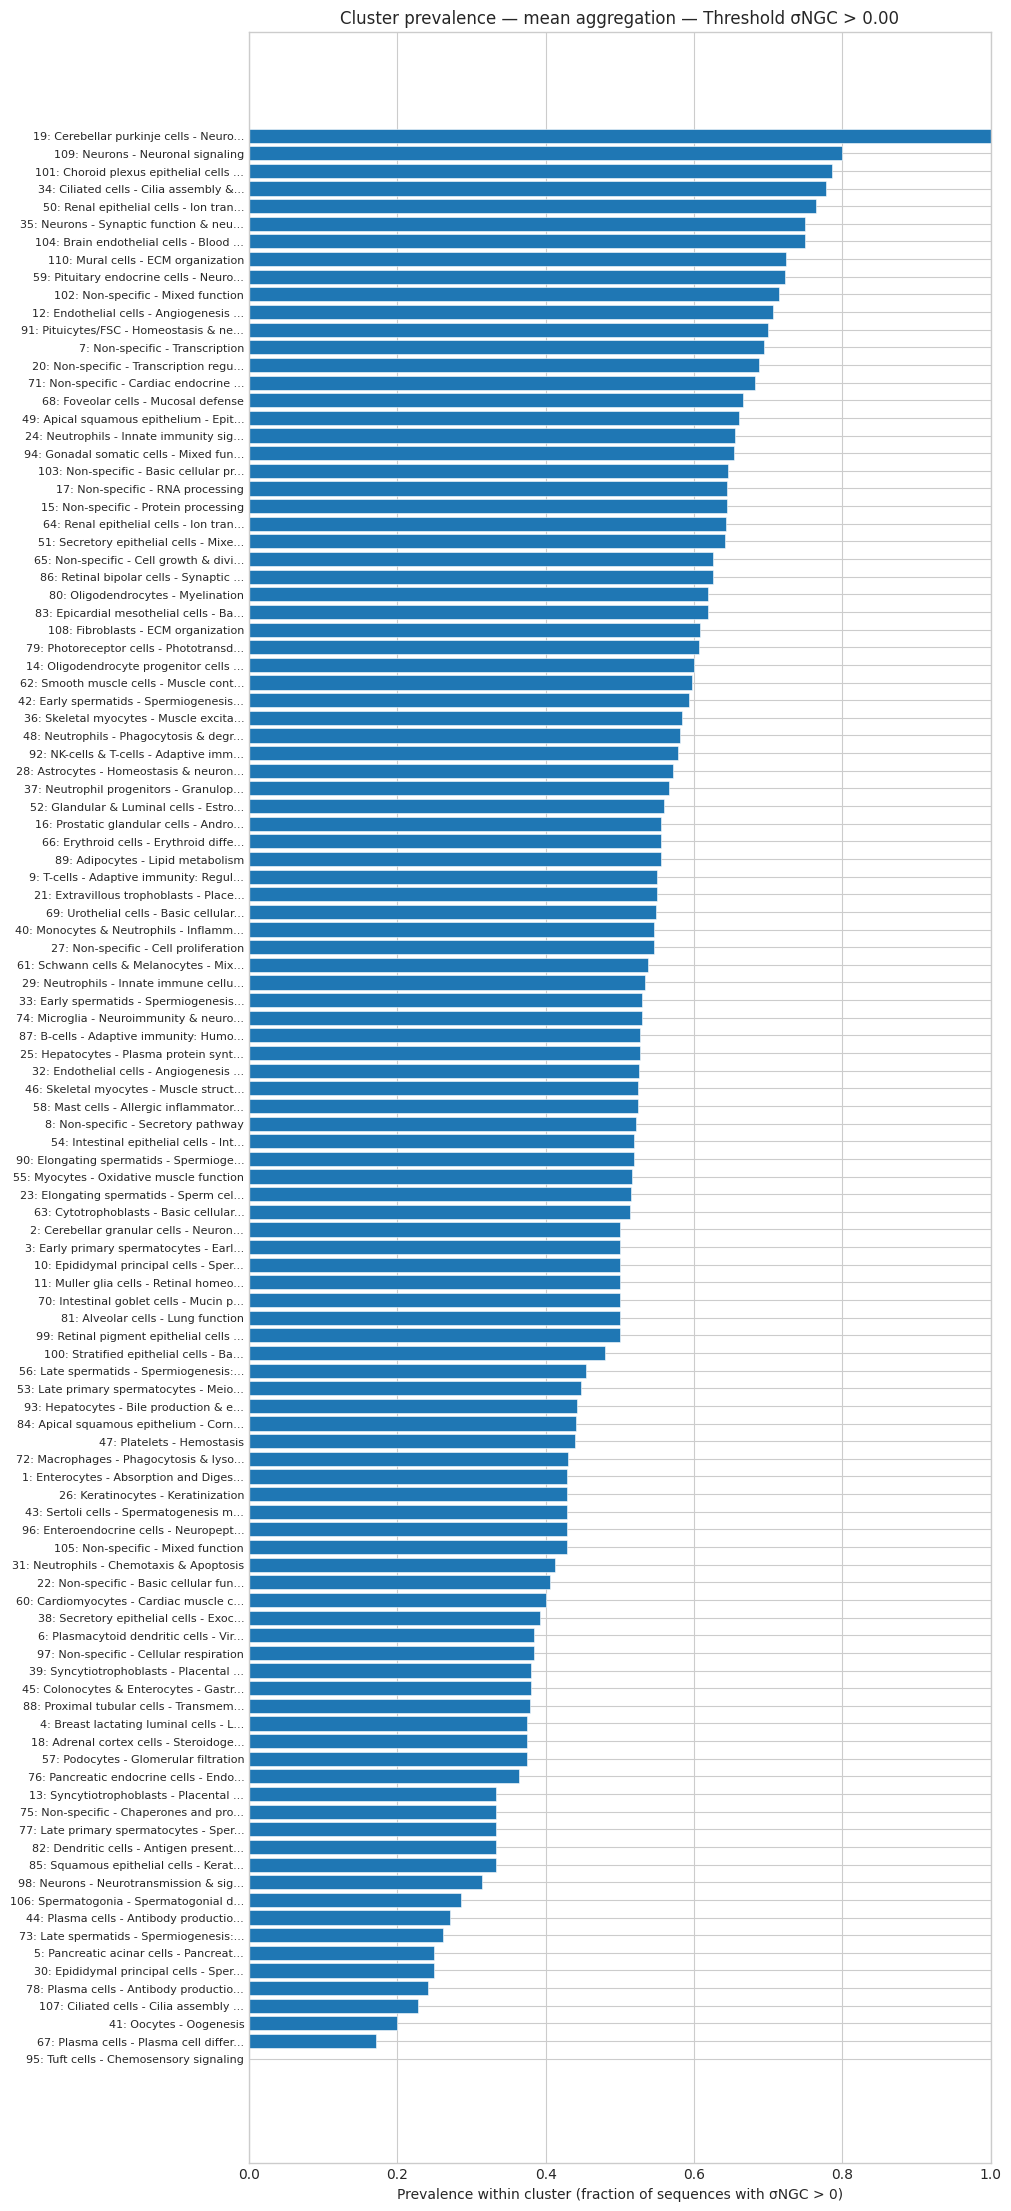

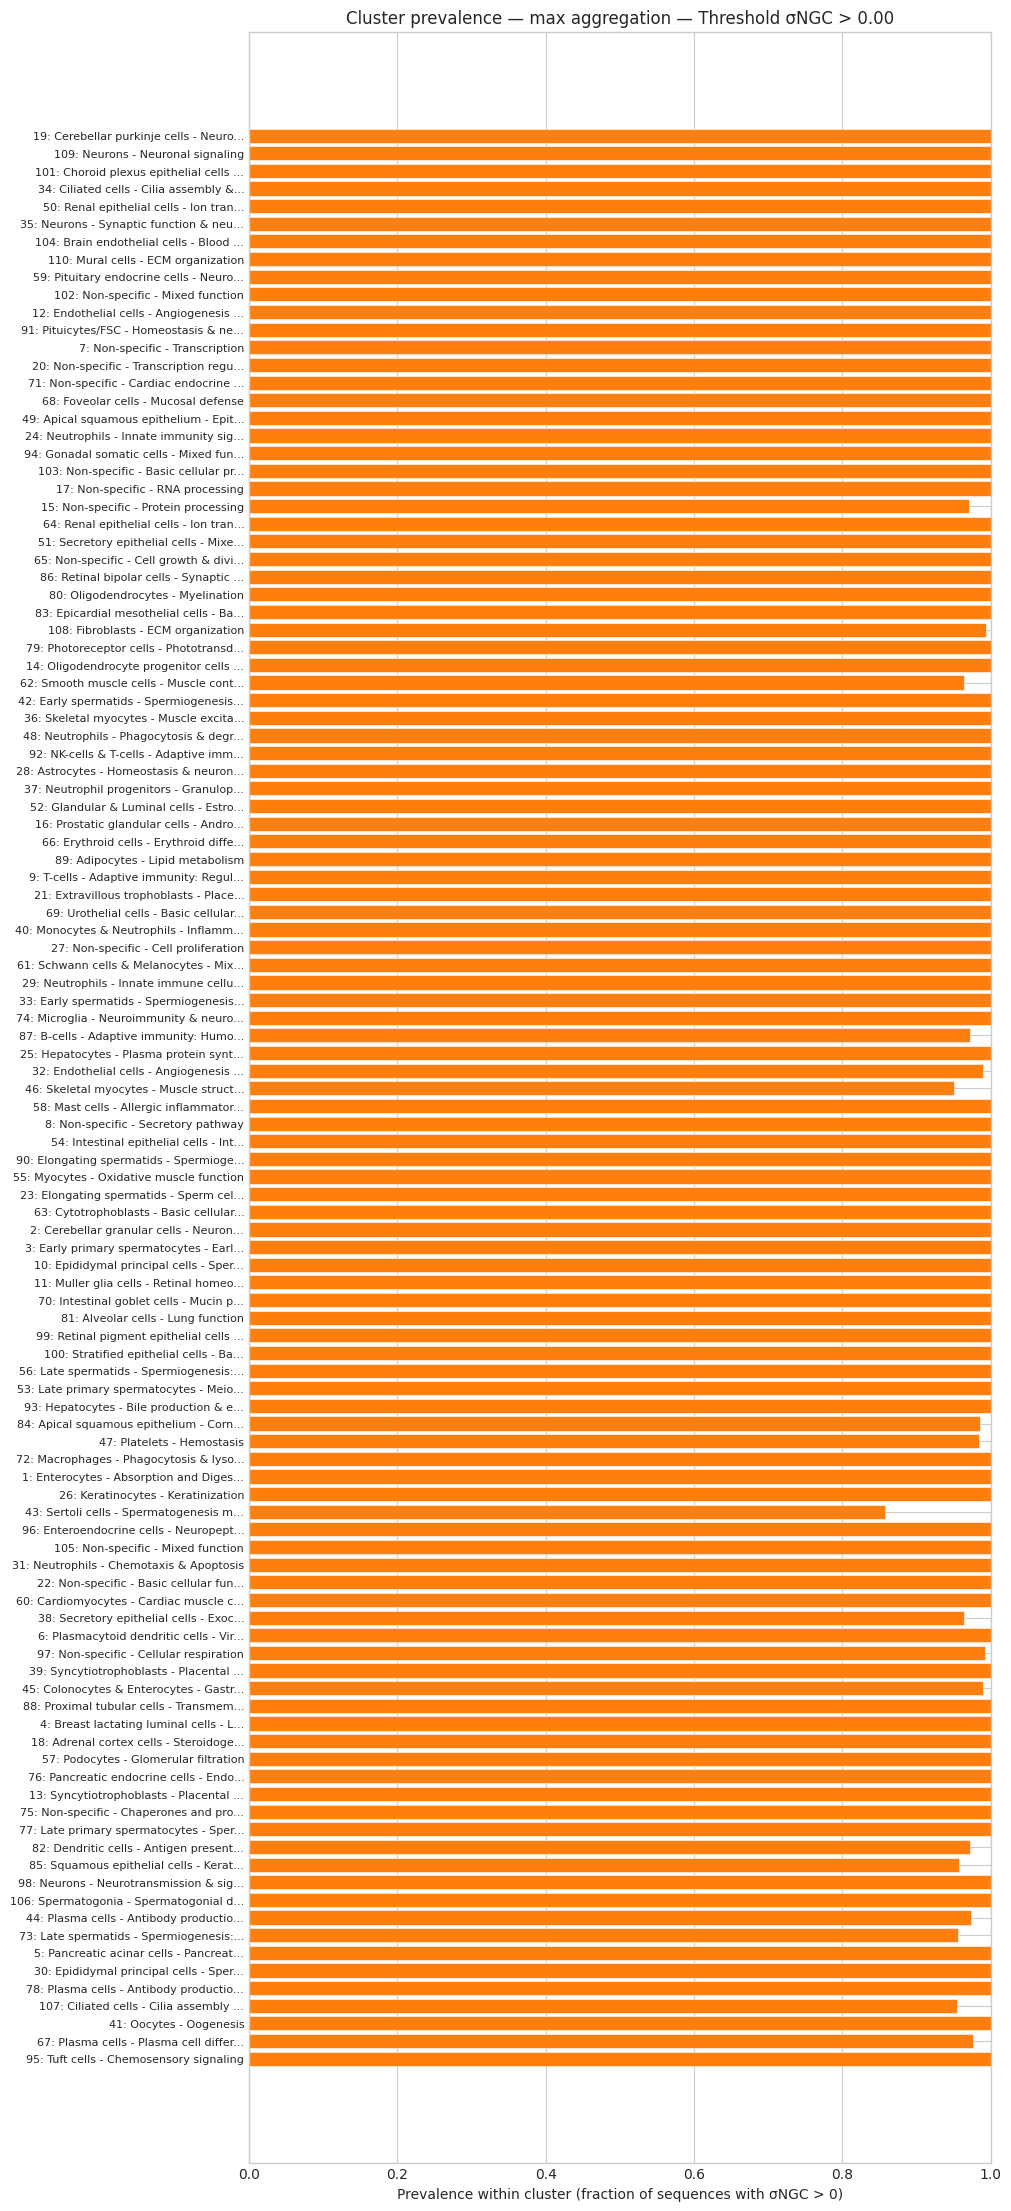

In [91]:
PERCENT_ACTIVATION_MAX_SIGMA_COLUMN = "hyperplane_distance_max_profile"
PERCENT_ACTIVATION_MAX_P_AMP_COLUMN = "p_amp_max_profile"


def groups_aligned_by_name(
    reference: list[ClusterGroup],
    other: list[ClusterGroup],
) -> list[ClusterGroup]:
    lookup = {group.name: group for group in other}
    missing = [group.name for group in reference if group.name not in lookup]
    if missing:
        raise ValueError(f"Missing clusters in the comparison set: {missing}")
    return [lookup[group.name] for group in reference]


def plot_cluster_prevalence_bars(
    groups: list[ClusterGroup],
    *,
    title: str,
    color: str,
) -> None:
    labels = [short_cluster_label(group.name, 40) for group in groups]
    values = np.asarray([group.prevalence for group in groups], dtype=np.float64)
    y = np.arange(len(groups))
    fig, ax = plt.subplots(
        figsize=(10.0, max(4.5, 0.2 * max(len(groups), 1))),
        layout="constrained",
    )
    ax.barh(y, values, color=color, edgecolor="white", linewidth=0.4)
    ax.set_yticks(y, labels)
    ax.invert_yaxis()
    ax.set_xlim(0.0, 1.0)
    ax.set_xlabel("Prevalence within cluster (fraction of sequences with σNGC > 0)")
    ax.set_title(f"{title} — {activity_boundary_label()}")
    ax.tick_params(axis="y", labelsize=8)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6, min_n_ticks=3))
    plt.show()


missing_max_columns = {PERCENT_ACTIVATION_MAX_SIGMA_COLUMN, PERCENT_ACTIVATION_MAX_P_AMP_COLUMN} - set(profiles_df.columns)
if missing_max_columns:
    raise ValueError(f"Profile CSV missing max-aggregation columns: {sorted(missing_max_columns)}")

dngc_rank_groups = build_cluster_groups(
    profiles_df,
    sigma_profile_column,
    p_amp_profile_column,
    limit=None,
)
prevalence_mean_groups = groups_aligned_by_name(
    dngc_rank_groups,
    build_cluster_groups(
        profiles_df,
        MEAN_SIGMA_COLUMN,
        MEAN_P_AMP_COLUMN,
        limit=None,
    ),
)
prevalence_max_groups = groups_aligned_by_name(
    dngc_rank_groups,
    build_cluster_groups(
        profiles_df,
        PERCENT_ACTIVATION_MAX_SIGMA_COLUMN,
        PERCENT_ACTIVATION_MAX_P_AMP_COLUMN,
        limit=None,
    ),
)

print(f"Prevalence for {len(prevalence_mean_groups)} clusters")
plot_cluster_prevalence_bars(
    prevalence_mean_groups,
    title="Cluster prevalence — mean aggregation",
    color="C0",
)
plot_cluster_prevalence_bars(
    prevalence_max_groups,
    title="Cluster prevalence — max aggregation",
    color="C1",
)


## Single cluster walkthrough

Inspect one cluster in detail. Cluster 19 has two sequences. Each sequence shows mean and max σNGC aggregation, with a DNGC = A / S line for both. The histogram is those per-sequence DNGC values.


Cluster 30: Cluster 30: Epididymal principal cells - Sperm storage microenvironment
Sequences: 4
DNGC = A / S
  S score = number of residues with σNGC > 0.00
  N = fragment count = contiguous runs with σNGC > 0.00
  A = sum of (σNGC - 0) on those residues
  F = S / sequence length


,id,name,length,S_mean,N_mean,A_mean,F_mean,DNGC_mean,DNGC_mean_formula,S_max,N_max,A_max,F_max,DNGC_max,DNGC_max_formula
0,sp|P49913|CAMP_HUMAN,Cathelicidin antimicrobial peptide,170,36,1,56.873559,0.211765,1.579821,56.8736 / 36,91,2,175.102845,0.535294,1.924207,175.103 / 91
1,sp|Q14696|MESD_HUMAN,LRP chaperone MESD,234,0,0,0.000000,0.000000,0.000000,0,65,3,29.507317,0.277778,0.453959,29.5073 / 65
2,sp|O43175|SERA_HUMAN,D-3-phosphoglycerate dehydrogenase,533,0,0,0.000000,0.000000,0.000000,0,217,9,124.107956,0.407129,0.571926,124.108 / 217
3,sp|O60831|PRAF2_HUMAN,PRA1 family protein 2,178,0,0,0.000000,0.000000,0.000000,0,97,1,124.483923,0.544944,1.283339,124.484 / 97


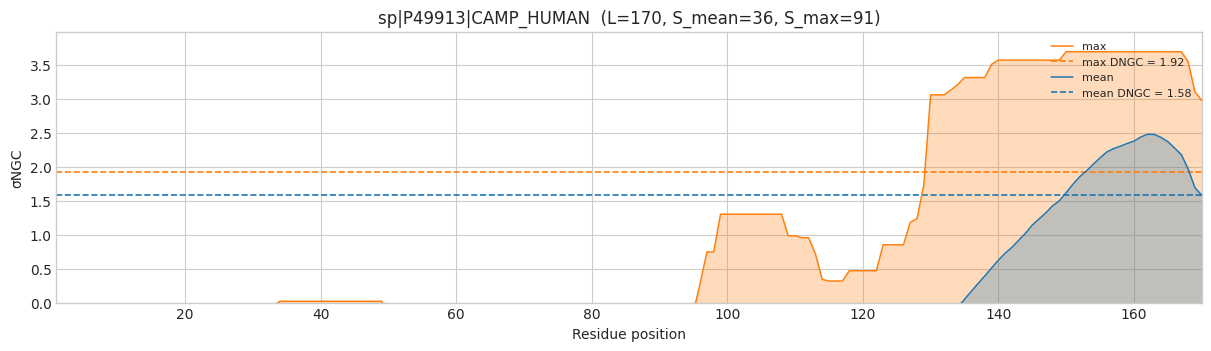

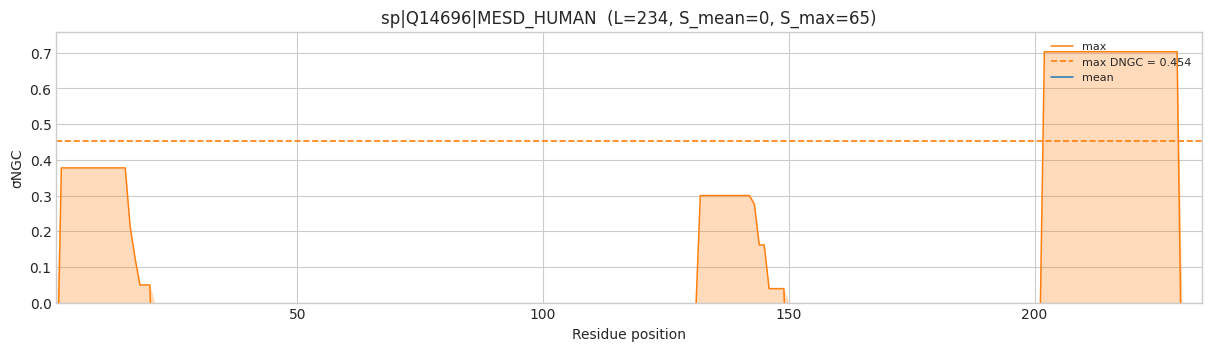

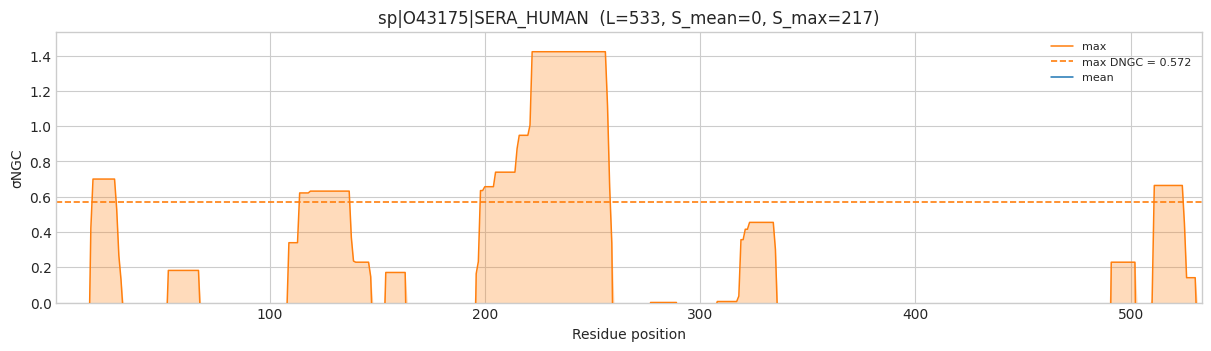

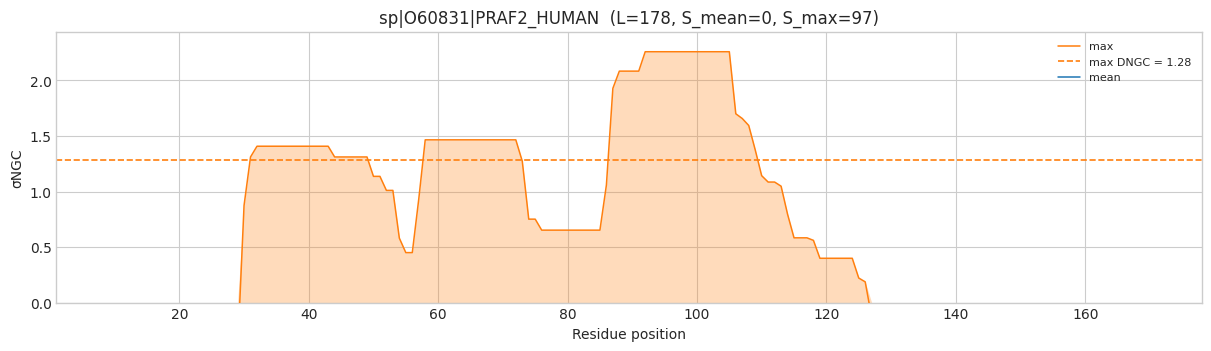

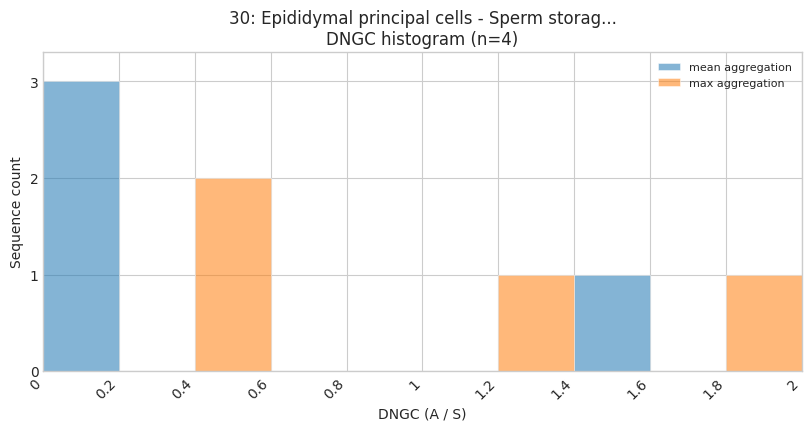

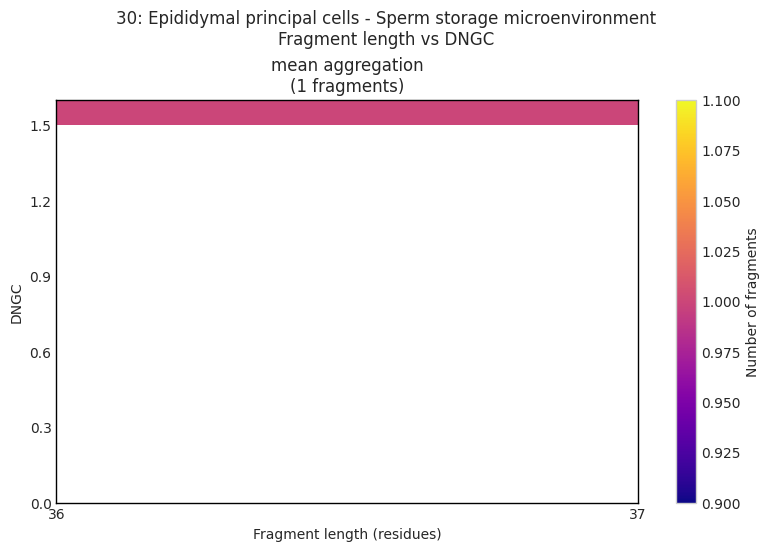

In [92]:
EXAMPLE_CLUSTER_NUMBER = 30
MAX_SIGMA_COLUMN = "hyperplane_distance_max_profile"
MAX_P_AMP_COLUMN = "p_amp_max_profile"
MEAN_PROFILE_COLOR = "C0"
MAX_PROFILE_COLOR = "C1"


def cluster_number_from_name(name: str) -> int | None:
    match = re.match(r"Cluster\s+(\d+)", name)
    return int(match.group(1)) if match else None


def find_cluster_by_number(groups: list[ClusterGroup], number: int) -> ClusterGroup:
    matches = [group for group in groups if cluster_number_from_name(group.name) == number]
    if len(matches) == 1:
        return matches[0]
    available = sorted(
        {value for value in (cluster_number_from_name(group.name) for group in groups) if value is not None}
    )
    if not matches:
        raise ValueError(f"Cluster {number} not found. Available cluster numbers: {available}")
    raise ValueError(f"Cluster {number} matched {len(matches)} groups.")


def example_cluster_group(number: int, sigma_column: str, p_amp_column: str) -> ClusterGroup:
    groups = build_cluster_groups(
        profiles_df,
        sigma_column,
        p_amp_column,
        limit=None,
    )
    return find_cluster_by_number(groups, number)


def pair_profiles_by_id(
    mean_group: ClusterGroup,
    max_group: ClusterGroup,
) -> list[tuple[SequenceProfile, SequenceProfile]]:
    max_lookup = {item.id: item for item in max_group.profiles}
    missing = [item.id for item in mean_group.profiles if item.id not in max_lookup]
    if missing:
        raise ValueError(f"Missing max-aggregation profiles: {missing}")
    extra = sorted(set(max_lookup) - {item.id for item in mean_group.profiles})
    if extra:
        raise ValueError(f"Extra max-aggregation profiles: {extra}")
    return [(item, max_lookup[item.id]) for item in mean_group.profiles]


def activity_breakdown(item: SequenceProfile, prefix: str) -> dict[str, object]:
    stats = item.statistics
    formula = "0" if stats.s_score == 0 else f"{stats.potency_auc:.6g} / {stats.s_score}"
    return {
        f"S_{prefix}": stats.s_score,
        f"N_{prefix}": stats.fragment_count,
        f"A_{prefix}": stats.potency_auc,
        f"F_{prefix}": stats.coverage,
        f"DNGC_{prefix}": stats.dngc,
        f"DNGC_{prefix}_formula": formula,
    }


def sequence_dngc_breakdown(
    mean_item: SequenceProfile,
    max_item: SequenceProfile,
) -> dict[str, object]:
    return {
        "id": mean_item.id,
        "name": mean_item.name,
        "length": mean_item.sequence_length,
        **activity_breakdown(mean_item, "mean"),
        **activity_breakdown(max_item, "max"),
    }


def draw_profile_sigma(ax, item: SequenceProfile, *, color: str, label: str) -> None:
    residue = np.arange(1, item.sequence_length + 1)
    sigma = np.nan_to_num(item.sigma, nan=0.0)
    active = activity_mask(item.sigma, item.p_amp)
    stats = item.statistics
    shown = np.where(active, np.maximum(sigma, SIGMA_ACTIVITY_THRESHOLD), SIGMA_ACTIVITY_THRESHOLD)
    ax.fill_between(
        residue,
        SIGMA_ACTIVITY_THRESHOLD,
        shown,
        color=color,
        alpha=0.28,
        linewidth=0,
    )
    ax.plot(residue, sigma, color=color, linewidth=1.1, zorder=3, label=label)
    if stats.s_score:
        ax.axhline(
            SIGMA_ACTIVITY_THRESHOLD + stats.dngc,
            color=color,
            linewidth=1.2,
            linestyle="--",
            label=f"{label} DNGC = {stats.dngc:.3g}",
        )


def draw_sequence_sigma_dngc(
    ax,
    mean_item: SequenceProfile,
    max_item: SequenceProfile,
) -> None:
    draw_profile_sigma(ax, max_item, color=MAX_PROFILE_COLOR, label="max")
    draw_profile_sigma(ax, mean_item, color=MEAN_PROFILE_COLOR, label="mean")
    ax.axhline(SIGMA_ACTIVITY_THRESHOLD, color="black", linewidth=0.7)
    stacked = np.vstack(
        [
            np.nan_to_num(mean_item.sigma, nan=0.0),
            np.nan_to_num(max_item.sigma, nan=0.0),
        ]
    )
    ax.set(
        xlim=(1, mean_item.sequence_length),
        ylim=_sigma_ylim(stacked),
        xlabel="Residue position",
        ylabel="σNGC",
        title=(
            f"{mean_item.id}  (L={mean_item.sequence_length}, "
            f"S_mean={mean_item.statistics.s_score}, "
            f"S_max={max_item.statistics.s_score})"
        ),
    )
    ax.legend(fontsize=8, loc="upper right")


def draw_cluster_dngc_histogram(
    ax,
    mean_group: ClusterGroup,
    max_group: ClusterGroup,
) -> None:
    mean_values = cluster_dngc_values(mean_group)
    max_values = cluster_dngc_values(max_group)
    bins = histogram_bins(np.concatenate([mean_values, max_values]))
    ax.hist(
        mean_values[np.isfinite(mean_values)],
        bins=bins,
        color=MEAN_PROFILE_COLOR,
        alpha=0.55,
        edgecolor="white",
        linewidth=0.6,
        label="mean aggregation",
    )
    ax.hist(
        max_values[np.isfinite(max_values)],
        bins=bins,
        color=MAX_PROFILE_COLOR,
        alpha=0.55,
        edgecolor="white",
        linewidth=0.6,
        label="max aggregation",
    )
    ax.set(
        xlim=(float(bins[0]), float(bins[-1])),
        xlabel="DNGC (A / S)",
        ylabel="Sequence count",
        title=f"{short_cluster_label(mean_group.name, 48)}\nDNGC histogram (n={mean_group.n})",
    )
    ax.margins(y=0.1)
    configure_histogram_x_axis(ax, bins)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend(fontsize=8, loc="upper right")


from matplotlib.ticker import MaxNLocator


def fragment_length_dngc(group: ClusterGroup) -> tuple[np.ndarray, np.ndarray]:
    lengths: list[float] = []
    scores: list[float] = []
    for item in group.profiles:
        for start, end, dngc in active_fragment_spans(item.sigma, item.p_amp):
            length = end - start
            if length <= 0 or not np.isfinite(dngc):
                continue
            lengths.append(float(length))
            scores.append(dngc)
    return np.asarray(lengths, dtype=np.float64), np.asarray(scores, dtype=np.float64)


def plot_fragment_length_dngc_heatmap(group: ClusterGroup, aggregation: str) -> None:
    lengths, scores = fragment_length_dngc(group)
    if lengths.size == 0:
        fig, ax = plt.subplots(figsize=(7.6, 5.4), layout="constrained")
        ax.set_facecolor("white")
        ax.grid(False)
        ax.set(xlabel="Fragment length (residues)", ylabel="DNGC", title=f"{aggregation} aggregation\nNo fragments")
        fig.suptitle(f"{short_cluster_label(group.name, 64)}\nFragment length vs DNGC")
        plt.show()
        return

    x_lo = float(np.floor(lengths.min()))
    x_hi = float(np.ceil(lengths.max()))
    if x_hi <= x_lo:
        x_hi = x_lo + 1.0
    y_hi = float(scores.max())
    y_step = 0.1 if y_hi <= 2.5 else 0.25
    y_hi = float(np.ceil((y_hi + 1e-9) / y_step) * y_step)
    x_edges = np.arange(x_lo, x_hi + 1.0, 1.0)
    y_edges = np.arange(0.0, y_hi + y_step * 0.5, y_step)
    fig, ax = plt.subplots(figsize=(7.6, 5.4), layout="constrained")
    ax.set_facecolor("white")
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")

    counts, _, _ = np.histogram2d(lengths, scores, bins=[x_edges, y_edges])
    masked = np.ma.masked_where(counts.T == 0, counts.T)
    peak = int(counts.max()) if counts.size else 1
    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        masked,
        cmap="plasma",
        vmin=1,
        vmax=max(peak, 1),
        shading="flat",
    )
    colorbar = fig.colorbar(mesh, ax=ax)
    colorbar.set_label("Number of fragments")
    colorbar.locator = MaxNLocator(integer=True, min_n_ticks=2)
    colorbar.update_ticks()

    ax.set_xlim(x_edges[0], x_edges[-1])
    ax.set_ylim(y_edges[0], y_edges[-1])
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6, min_n_ticks=2))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6, min_n_ticks=2))
    ax.set(
        xlabel="Fragment length (residues)",
        ylabel="DNGC",
        title=f"{aggregation} aggregation\n({int(lengths.size)} fragments)",
    )
    fig.suptitle(f"{short_cluster_label(group.name, 64)}\nFragment length vs DNGC")
    plt.show()


missing_max_columns = {MAX_SIGMA_COLUMN, MAX_P_AMP_COLUMN} - set(profiles_df.columns)
if missing_max_columns:
    raise ValueError(f"Profile CSV missing max-aggregation columns: {sorted(missing_max_columns)}")

example_mean_group = example_cluster_group(EXAMPLE_CLUSTER_NUMBER, MEAN_SIGMA_COLUMN, MEAN_P_AMP_COLUMN)
example_max_group = example_cluster_group(EXAMPLE_CLUSTER_NUMBER, MAX_SIGMA_COLUMN, MAX_P_AMP_COLUMN)
example_pairs = pair_profiles_by_id(example_mean_group, example_max_group)
print(f"Cluster {EXAMPLE_CLUSTER_NUMBER}: {example_mean_group.name}")
print(f"Sequences: {example_mean_group.n}")
print("DNGC = A / S")
print(f"  S score = number of residues with σNGC > {SIGMA_ACTIVITY_THRESHOLD:.2f}")
print(f"  N = fragment count = contiguous runs with σNGC > {SIGMA_ACTIVITY_THRESHOLD:.2f}")
print(f"  A = sum of (σNGC - {SIGMA_ACTIVITY_THRESHOLD:.4g}) on those residues")
print("  F = S / sequence length")

breakdown = pd.DataFrame([sequence_dngc_breakdown(mean_item, max_item) for mean_item, max_item in example_pairs])
display(breakdown)

for mean_item, max_item in example_pairs:
    fig, ax = plt.subplots(figsize=(12.0, 3.4), layout="constrained")
    draw_sequence_sigma_dngc(ax, mean_item, max_item)
    plt.show()

fig, ax = plt.subplots(figsize=(8.0, 4.2), layout="constrained")
draw_cluster_dngc_histogram(ax, example_mean_group, example_max_group)
plt.show()

example_groups = {"mean": example_mean_group, "max": example_max_group}
plot_fragment_length_dngc_heatmap(
    example_groups[PROFILE_AGGREGATION_MODE],
    PROFILE_AGGREGATION_MODE,
)


## Mean vs max aggregation overlay

Top 9 clusters by curvature load (same ranking as the other graphs), shown as 3×3 grids. Mean and max aggregation are overlapped; σNGC uses the cluster-max envelope.


In [93]:
OVERLAY_ROWS = 3
OVERLAY_COLS = 3
OVERLAY_TOP_N = OVERLAY_ROWS * OVERLAY_COLS
OVERLAY_MEAN_COLOR = "C0"
OVERLAY_MAX_COLOR = "C1"
MAX_SIGMA_COLUMN = "hyperplane_distance_max_profile"
MAX_P_AMP_COLUMN = "p_amp_max_profile"


def groups_by_name(groups: list[ClusterGroup]) -> dict[str, ClusterGroup]:
    return {group.name: group for group in groups}


def aligned_mode_pairs(
    mean_groups: list[ClusterGroup],
    max_groups: list[ClusterGroup],
) -> list[tuple[ClusterGroup, ClusterGroup]]:
    max_lookup = groups_by_name(max_groups)
    missing = [group.name for group in mean_groups if group.name not in max_lookup]
    if missing:
        raise ValueError(f"Missing max-aggregation clusters: {missing}")
    return [(group, max_lookup[group.name]) for group in mean_groups]


def overlay_panel_title(mean_group: ClusterGroup, max_group: ClusterGroup) -> str:
    if mean_group.n != max_group.n:
        raise ValueError(
            f"{mean_group.name}: mean/max protein counts differ ({mean_group.n} vs {max_group.n})."
        )
    return (
        f"{short_cluster_label(mean_group.name, 34)}\n"
        f"(n={mean_group.n}, prevalence={mean_group.mean_profile_prevalence:.2f})"
    )


def overlay_shared_sigma_ylim(
    pairs: list[tuple[ClusterGroup, ClusterGroup]],
) -> tuple[float, float]:
    envelopes = []
    for mean_group, max_group in pairs:
        envelopes.append(positive_sigma(cluster_sigma_envelope(mean_group)))
        envelopes.append(positive_sigma(cluster_sigma_envelope(max_group)))
    if not envelopes:
        return (SIGMA_ACTIVITY_THRESHOLD, SIGMA_ACTIVITY_THRESHOLD + 0.1)
    return _sigma_ylim(np.vstack(envelopes))


def overlay_concatenated_metric_values(pairs, values_from_group) -> np.ndarray:
    chunks = []
    for mean_group, max_group in pairs:
        chunks.append(np.asarray(values_from_group(mean_group), dtype=np.float64))
        chunks.append(np.asarray(values_from_group(max_group), dtype=np.float64))
    return np.concatenate(chunks) if chunks else np.empty(0, dtype=np.float64)


def draw_sigma_mean_max_overlay(
    ax,
    mean_group: ClusterGroup,
    max_group: ClusterGroup,
    ylim: tuple[float, float] | None = None,
) -> None:
    x = np.linspace(0.0, 1.0, PROFILE_GRID)
    mean_env = positive_sigma(cluster_sigma_envelope(mean_group))
    max_env = positive_sigma(cluster_sigma_envelope(max_group))
    ax.fill_between(
        x,
        SIGMA_ACTIVITY_THRESHOLD,
        max_env,
        color=OVERLAY_MAX_COLOR,
        linewidth=0,
        alpha=0.4,
        zorder=2,
        label="max aggregation",
    )
    ax.fill_between(
        x,
        SIGMA_ACTIVITY_THRESHOLD,
        mean_env,
        color=OVERLAY_MEAN_COLOR,
        linewidth=0,
        alpha=0.55,
        zorder=3,
        label="mean aggregation",
    )
    ax.axhline(SIGMA_ACTIVITY_THRESHOLD, color="black", linewidth=0.7, zorder=4)
    ax.set(
        xlim=(0.0, 1.0),
        ylim=ylim if ylim is not None else _sigma_ylim(np.vstack([mean_env, max_env])),
        xlabel="Relative residue position",
        ylabel="positive σNGC",
        title=overlay_panel_title(mean_group, max_group),
    )


def draw_metric_mean_max_overlay(
    ax,
    mean_group: ClusterGroup,
    max_group: ClusterGroup,
    *,
    values_from_group,
    xlabel: str,
    all_zero_message: str,
    bins: np.ndarray,
    ylim: tuple[float, float] | None = None,
) -> None:
    mean_values = np.asarray(values_from_group(mean_group), dtype=np.float64)
    max_values = np.asarray(values_from_group(max_group), dtype=np.float64)
    ax.hist(
        mean_values[np.isfinite(mean_values)],
        bins=bins,
        color=OVERLAY_MEAN_COLOR,
        alpha=0.55,
        edgecolor="white",
        linewidth=0.6,
        label="mean aggregation",
    )
    ax.hist(
        max_values[np.isfinite(max_values)],
        bins=bins,
        color=OVERLAY_MAX_COLOR,
        alpha=0.55,
        edgecolor="white",
        linewidth=0.6,
        label="max aggregation",
    )
    finite = np.concatenate([mean_values, max_values])
    finite = finite[np.isfinite(finite)]
    if finite.size and np.allclose(finite, 0.0):
        ax.text(
            0.5,
            0.88,
            all_zero_message.format(count=finite.size),
            ha="center",
            transform=ax.transAxes,
            fontsize=8,
        )
    ax.set(
        xlim=(float(bins[0]), float(bins[-1])),
        xlabel=xlabel,
        ylabel="Sequence count",
        title=overlay_panel_title(mean_group, max_group),
    )
    configure_histogram_x_axis(ax, bins)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    if ylim is None:
        ax.margins(y=0.1)
    else:
        ax.set_ylim(ylim)


def overlay_legend_handles():
    from matplotlib.patches import Patch

    return [
        Patch(facecolor=OVERLAY_MEAN_COLOR, alpha=0.55, label="mean aggregation"),
        Patch(facecolor=OVERLAY_MAX_COLOR, alpha=0.4, label="max aggregation"),
    ]


def render_overlay_grid(pairs, draw, suptitle: str):
    fig = plt.figure(figsize=(16.0, 14.0), layout="constrained")
    grid = fig.add_gridspec(
        OVERLAY_ROWS + 1,
        OVERLAY_COLS,
        height_ratios=[0.22, *([1.0] * OVERLAY_ROWS)],
    )
    header = fig.add_subplot(grid[0, :])
    header.set_axis_off()
    header.set_title(f"{suptitle} — {activity_boundary_label()}", fontsize=13, pad=4)
    header.legend(
        handles=overlay_legend_handles(),
        loc="lower center",
        ncol=2,
        fontsize=10,
        frameon=True,
    )
    axes = [
        fig.add_subplot(grid[row + 1, col])
        for row in range(OVERLAY_ROWS)
        for col in range(OVERLAY_COLS)
    ]
    for ax, (mean_group, max_group) in zip(axes, pairs):
        draw(ax, mean_group, max_group)
    for ax in axes[len(pairs) :]:
        ax.set_visible(False)
    return fig


def plot_overlay_grid(pairs, draw, suptitle: str) -> None:
    render_overlay_grid(pairs, draw, suptitle)
    plt.show()


def make_sigma_overlay_draw(pairs):
    ylim = overlay_shared_sigma_ylim(pairs) if SCALE_HISTOGRAM_Y else None

    def draw(ax, mean_group: ClusterGroup, max_group: ClusterGroup) -> None:
        draw_sigma_mean_max_overlay(ax, mean_group, max_group, ylim=ylim)

    return draw


def make_metric_overlay_draw(values_from_group, xlabel: str, all_zero_message: str):
    arrays = []
    for mean_group, max_group in overlay_pairs:
        arrays.append(np.asarray(values_from_group(mean_group), dtype=np.float64))
        arrays.append(np.asarray(values_from_group(max_group), dtype=np.float64))
    bins = histogram_bins(
        np.concatenate(arrays) if arrays else np.empty(0, dtype=np.float64)
    )
    ylim = shared_histogram_ylim(arrays, bins) if SCALE_HISTOGRAM_Y else None

    def draw(ax, mean_group: ClusterGroup, max_group: ClusterGroup) -> None:
        draw_metric_mean_max_overlay(
            ax,
            mean_group,
            max_group,
            values_from_group=values_from_group,
            xlabel=xlabel,
            all_zero_message=all_zero_message,
            bins=bins,
            ylim=ylim,
        )

    return draw


required_max_columns = {MAX_SIGMA_COLUMN, MAX_P_AMP_COLUMN} - set(profiles_df.columns)
if required_max_columns:
    raise ValueError(f"Profile CSV missing max-aggregation columns: {sorted(required_max_columns)}")

ranked_clusters = build_cluster_groups(
    profiles_df,
    sigma_profile_column,
    p_amp_profile_column,
    limit=None,
)
top_ranked_clusters = ranked_clusters[:OVERLAY_TOP_N]
top_names = {group.name for group in top_ranked_clusters}
mean_clusters_top = groups_aligned_by_name(
    top_ranked_clusters,
    build_cluster_groups(
        profiles_df,
        MEAN_SIGMA_COLUMN,
        MEAN_P_AMP_COLUMN,
        cluster_names=top_names,
        limit=None,
    ),
)
max_clusters_top = groups_aligned_by_name(
    top_ranked_clusters,
    build_cluster_groups(
        profiles_df,
        MAX_SIGMA_COLUMN,
        MAX_P_AMP_COLUMN,
        cluster_names=top_names,
        limit=None,
    ),
)
overlay_pairs = aligned_mode_pairs(mean_clusters_top, max_clusters_top)

print(f"Top {len(top_ranked_clusters)} clusters by {CLUSTER_ORDER_BY} ({PROFILE_AGGREGATION_MODE} aggregation):")
for rank, group in enumerate(top_ranked_clusters, start=1):
    print(f"  {rank}. {group.name}: {CLUSTER_ORDER_BY}={group.rank_score:.4g}")


Top 9 clusters by prevalence (mean aggregation):
  1. Cluster 19: Cerebellar purkinje cells - Neurotransmission & signaling: prevalence=1
  2. Cluster 109: Neurons - Neuronal signaling: prevalence=0.8
  3. Cluster 101: Choroid plexus epithelial cells - Ion transport: prevalence=0.7857
  4. Cluster 34: Ciliated cells - Cilia assembly & function: prevalence=0.7778
  5. Cluster 50: Renal epithelial cells - Ion transport and pH regulation: prevalence=0.7647
  6. Cluster 35: Neurons - Synaptic function & neurogenesis: prevalence=0.75
  7. Cluster 104: Brain endothelial cells - Blood brain barrier: prevalence=0.75
  8. Cluster 110: Mural cells - ECM organization: prevalence=0.7241
  9. Cluster 59: Pituitary endocrine cells - Neuroendocrine signaling: prevalence=0.7222


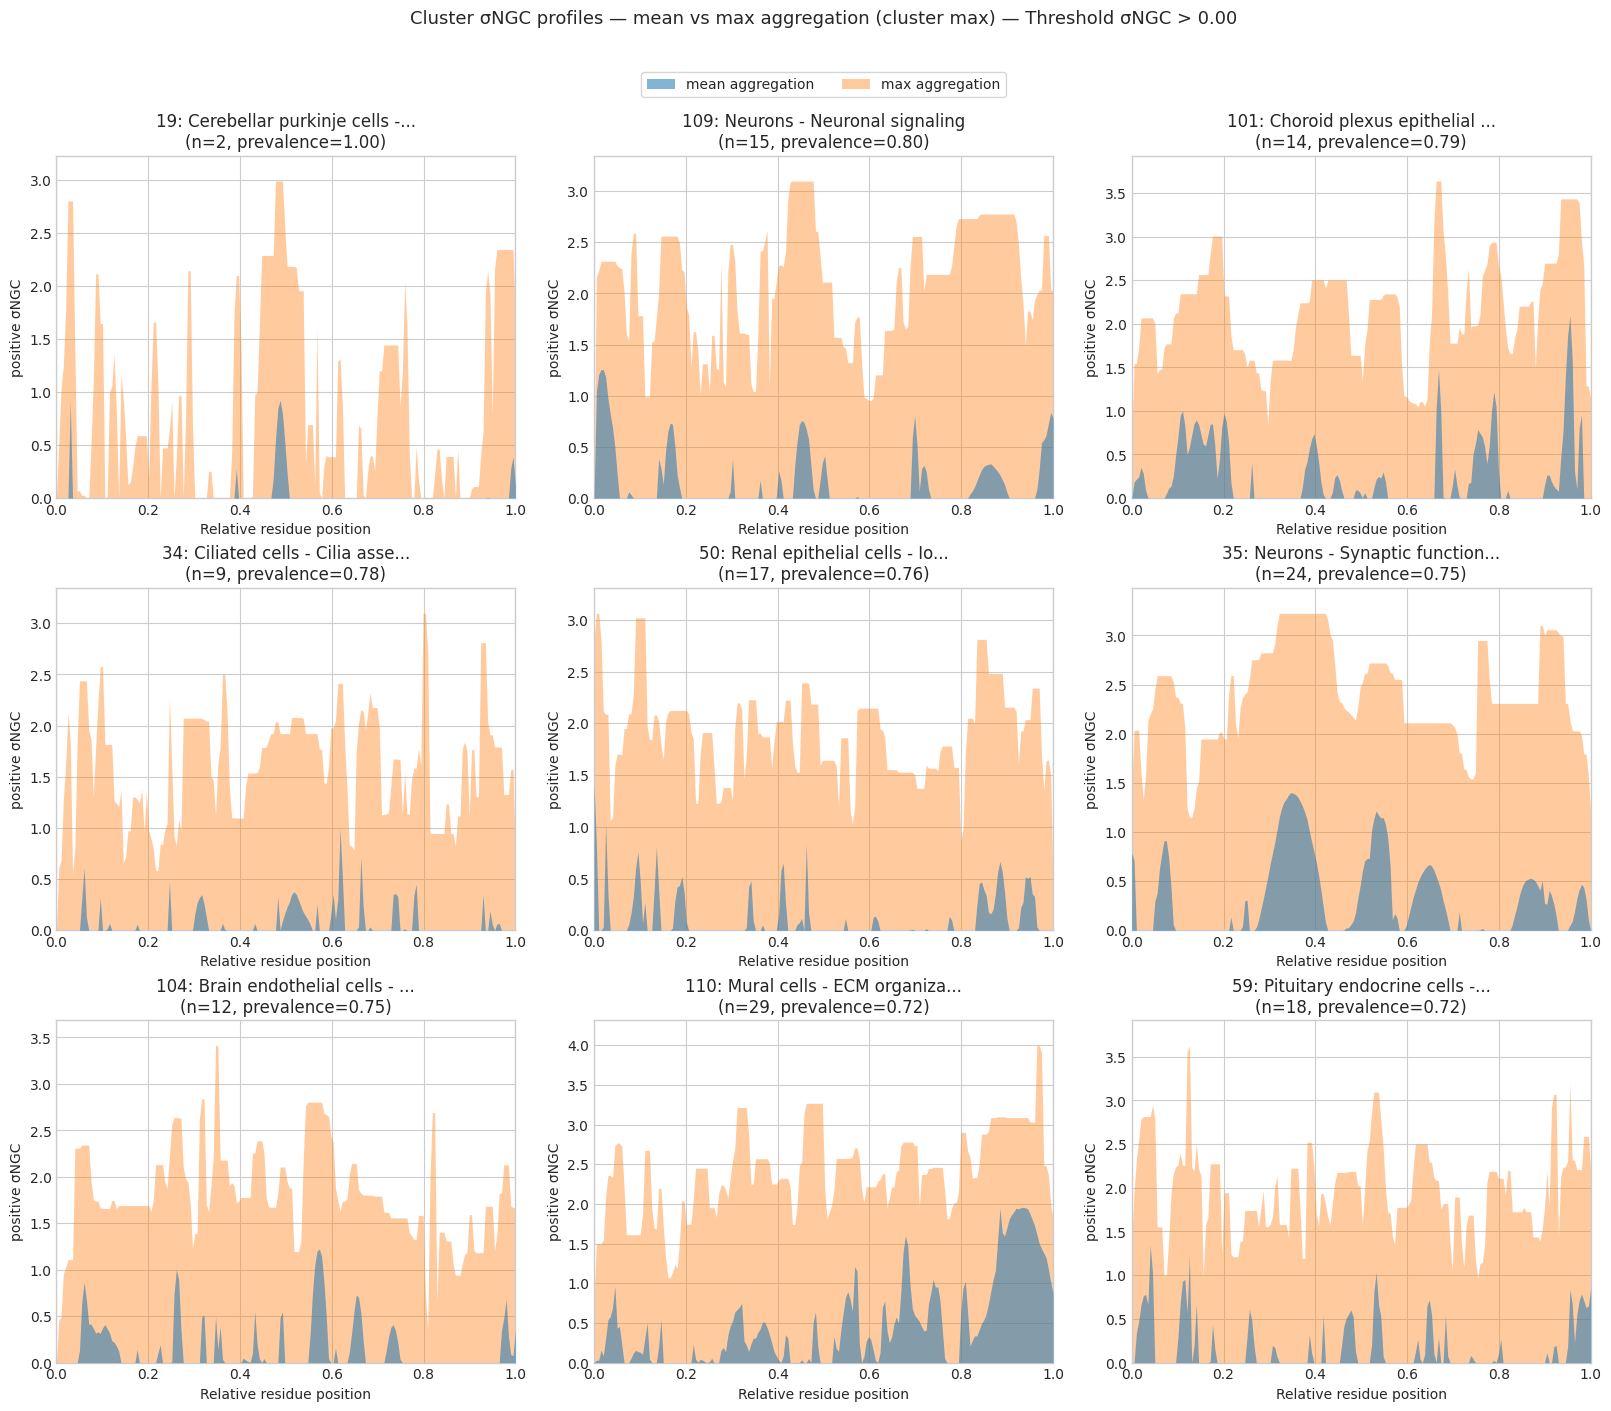

In [94]:
# sigmaNGC comparisons
plot_overlay_grid(
    overlay_pairs,
    make_sigma_overlay_draw(overlay_pairs),
    "Cluster σNGC profiles — mean vs max aggregation (cluster max)",
)

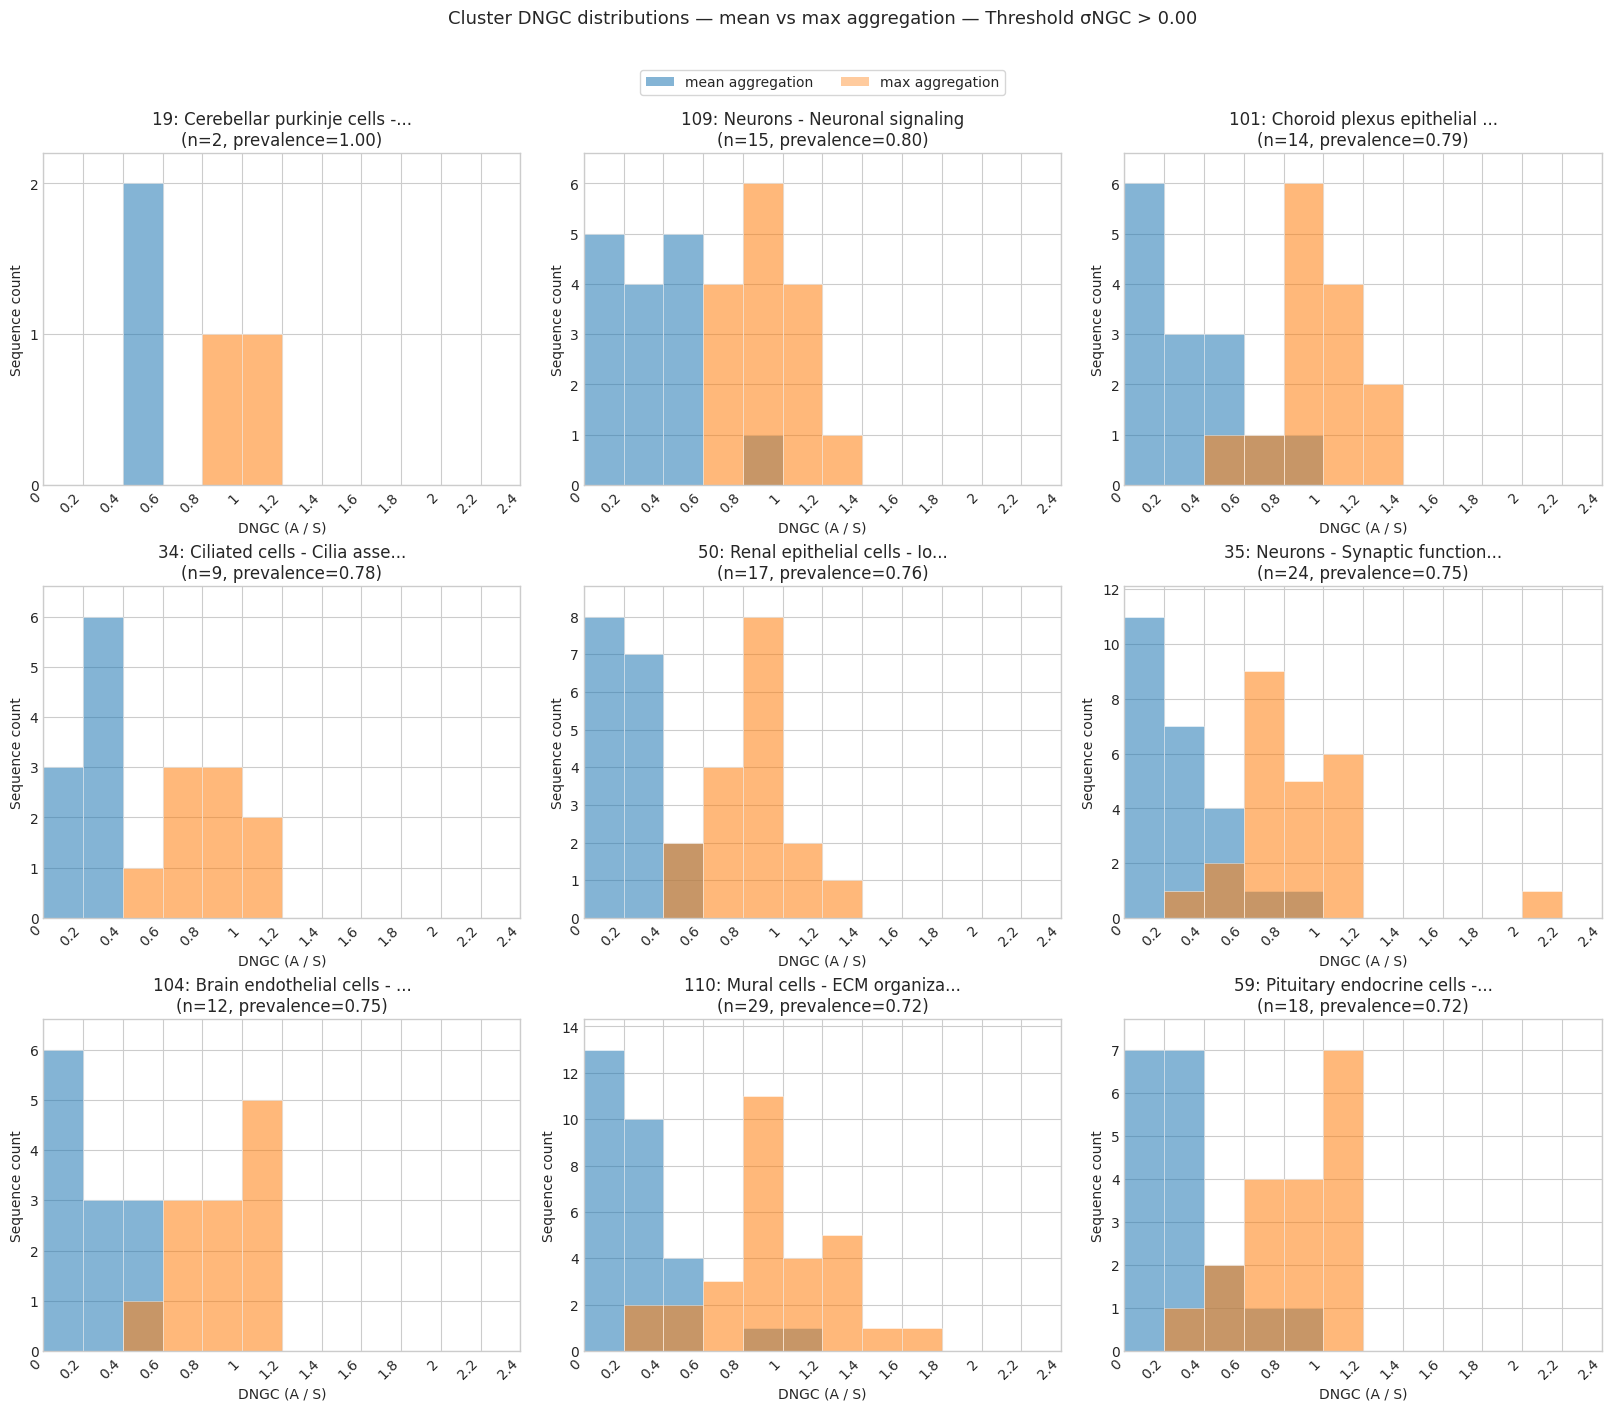

In [95]:
# DNGC
plot_overlay_grid(
    overlay_pairs,
    make_metric_overlay_draw(
        cluster_dngc_values,
        "DNGC (A / S)",
        "All sequences have DNGC = 0",
    ),
    "Cluster DNGC distributions — mean vs max aggregation",
)


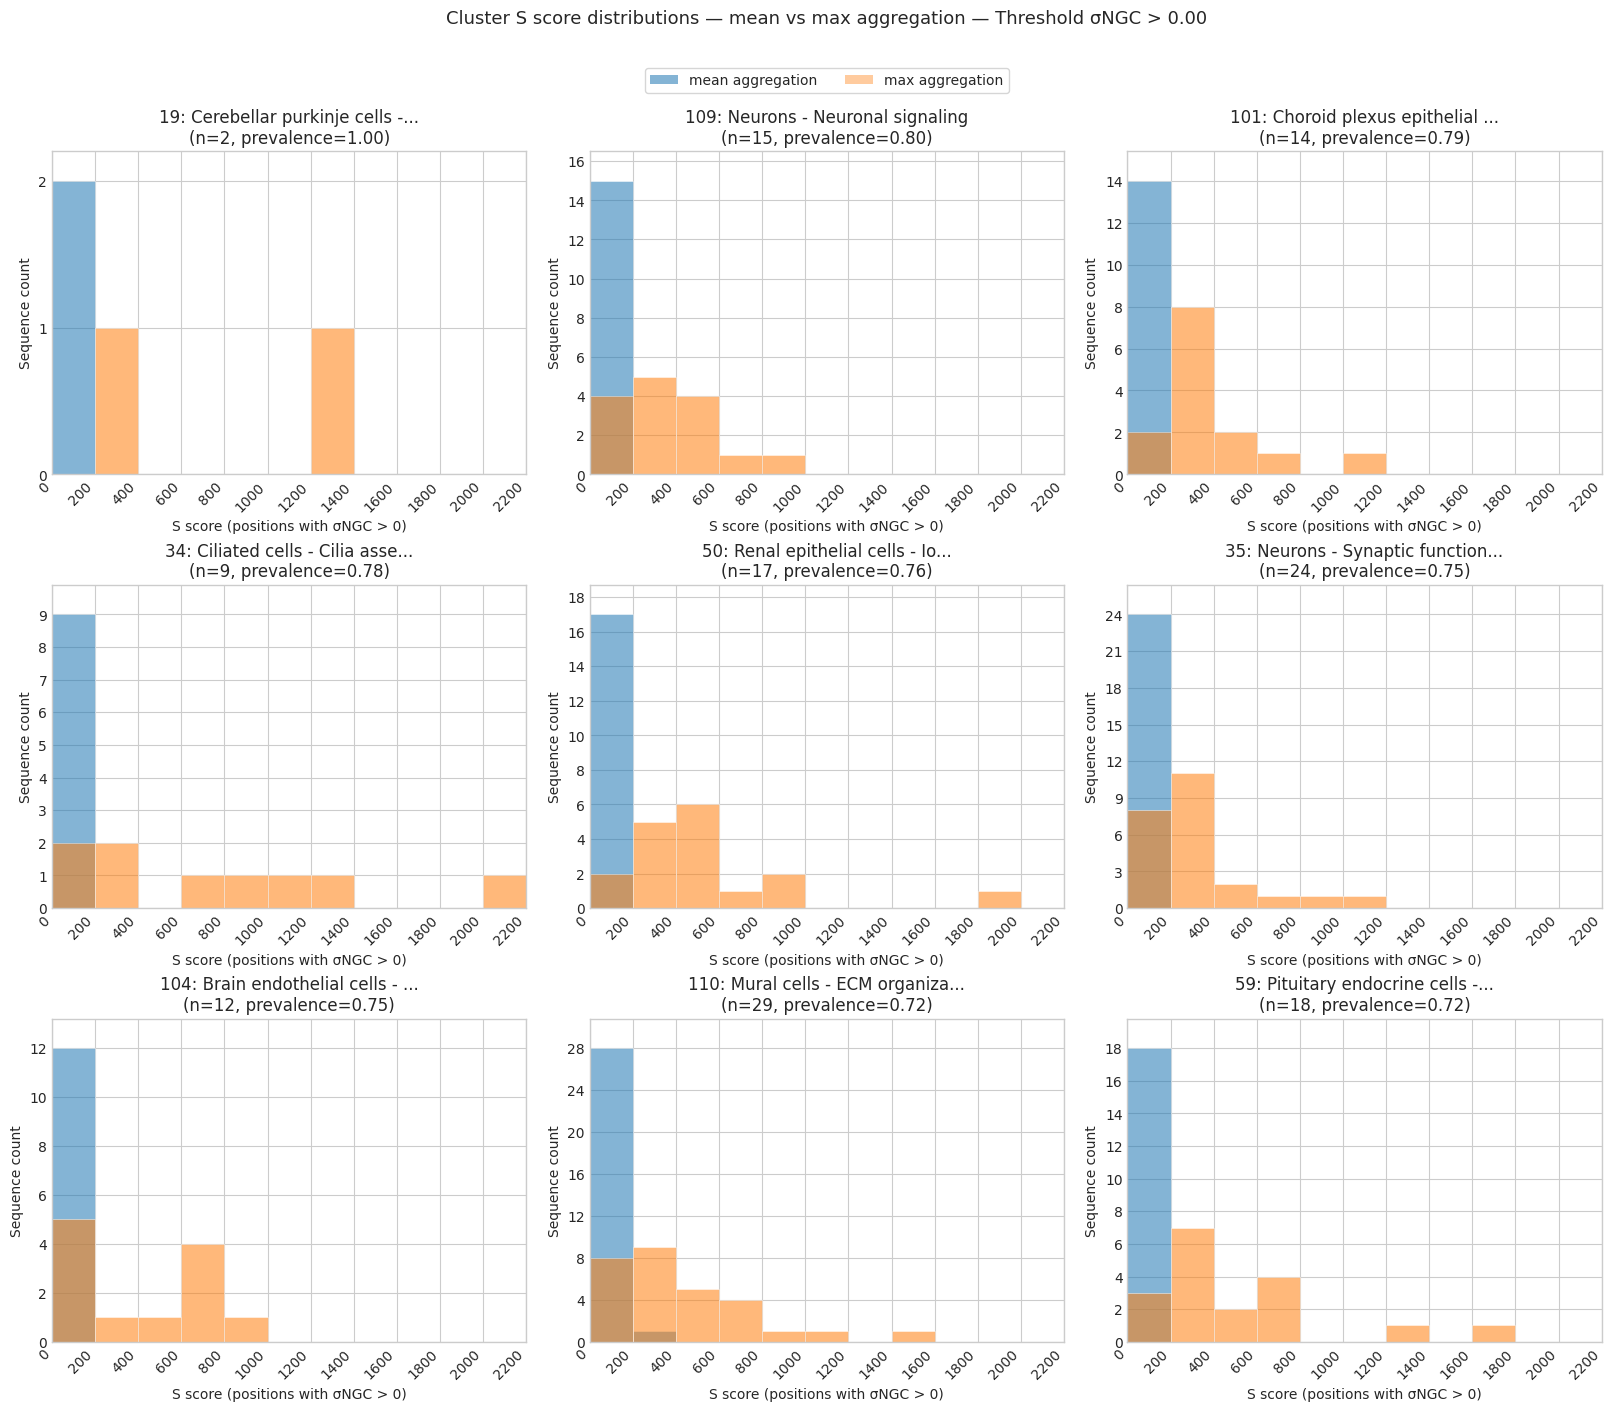

In [96]:
# S score
plot_overlay_grid(
    overlay_pairs,
    make_metric_overlay_draw(
        sequence_s_score_values,
        "S score (positions with σNGC > 0)",
        "All sequences have S = 0",
    ),
    "Cluster S score distributions — mean vs max aggregation",
)


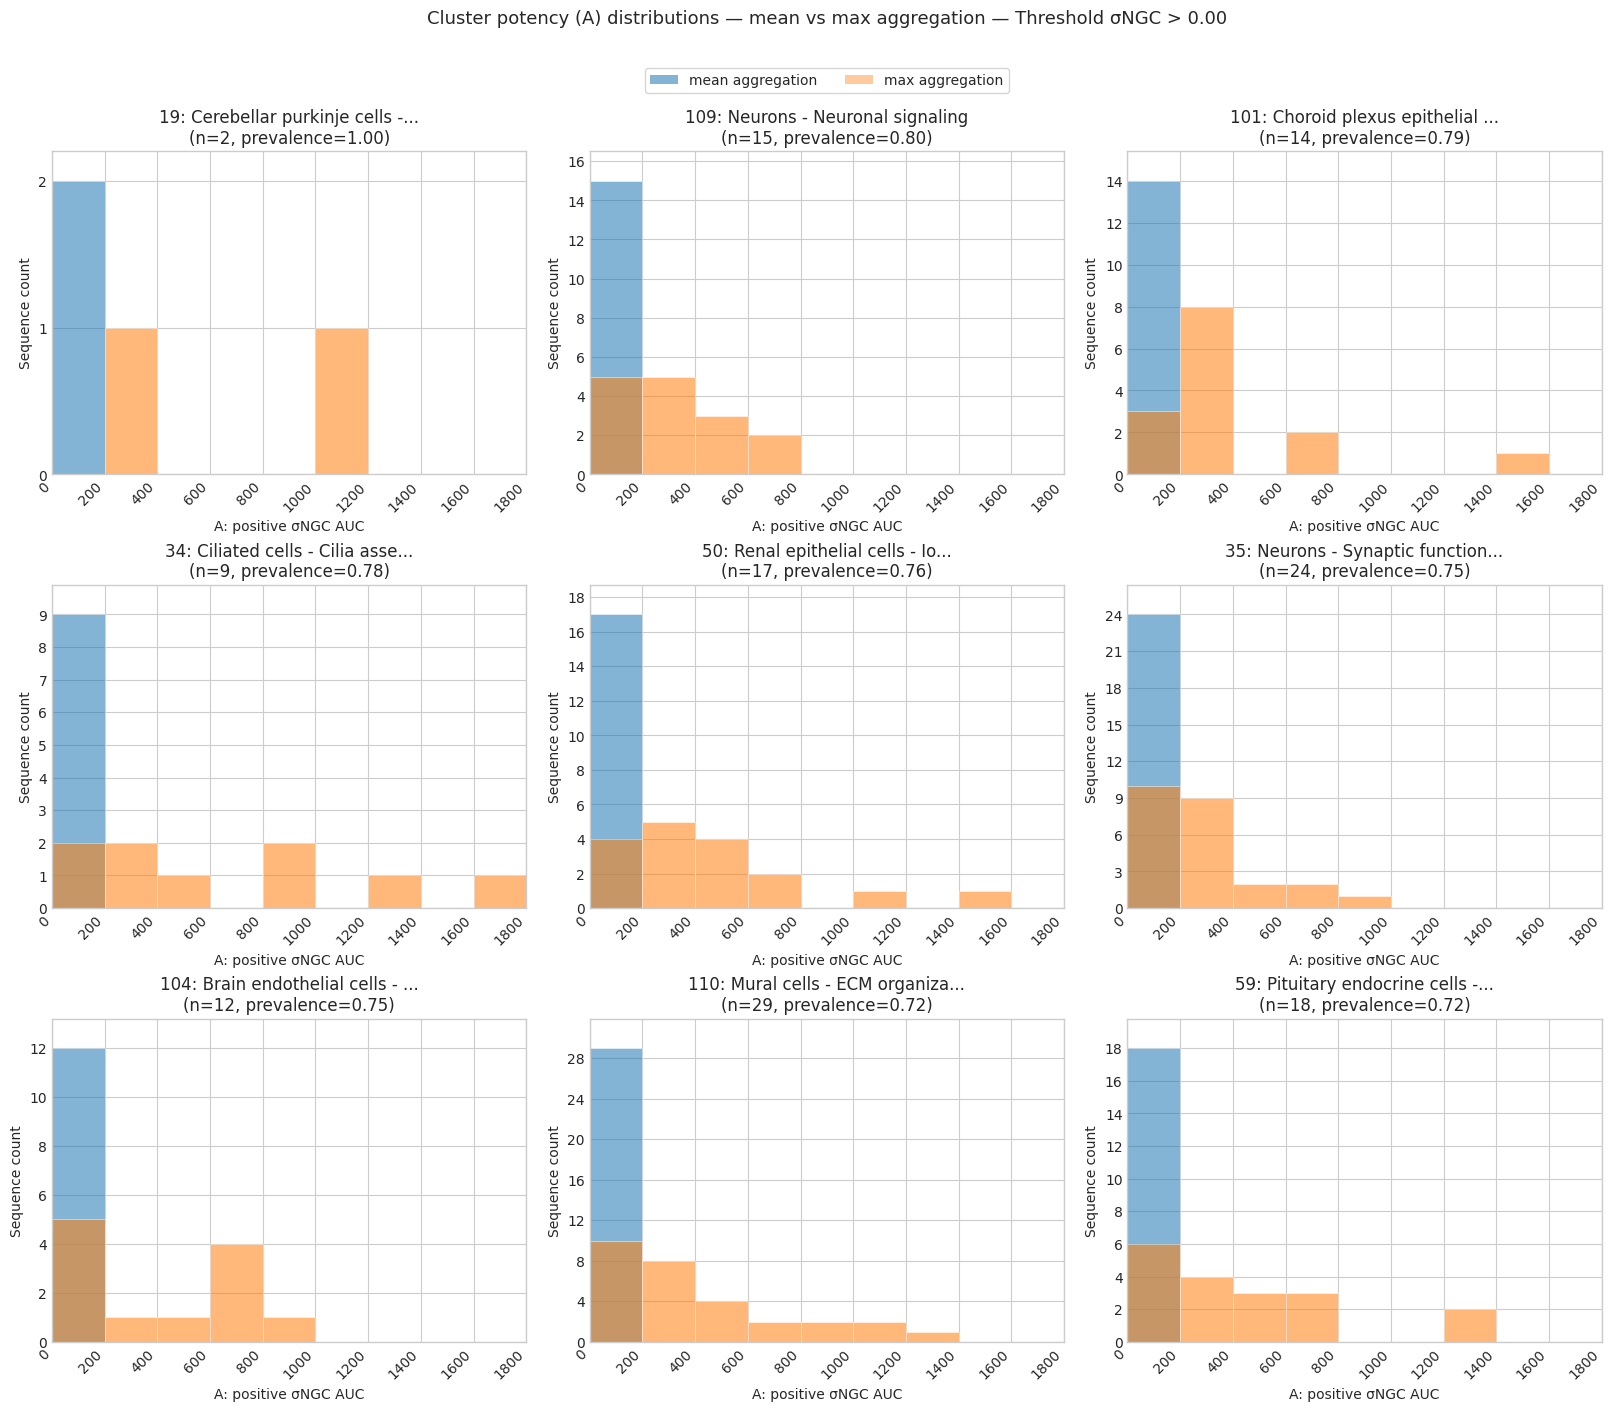

In [97]:
# potency
plot_overlay_grid(
    overlay_pairs,
    make_metric_overlay_draw(
        sequence_a_values,
        "A: positive σNGC AUC",
        "All sequences have A = 0",
    ),
    "Cluster potency (A) distributions — mean vs max aggregation",
)

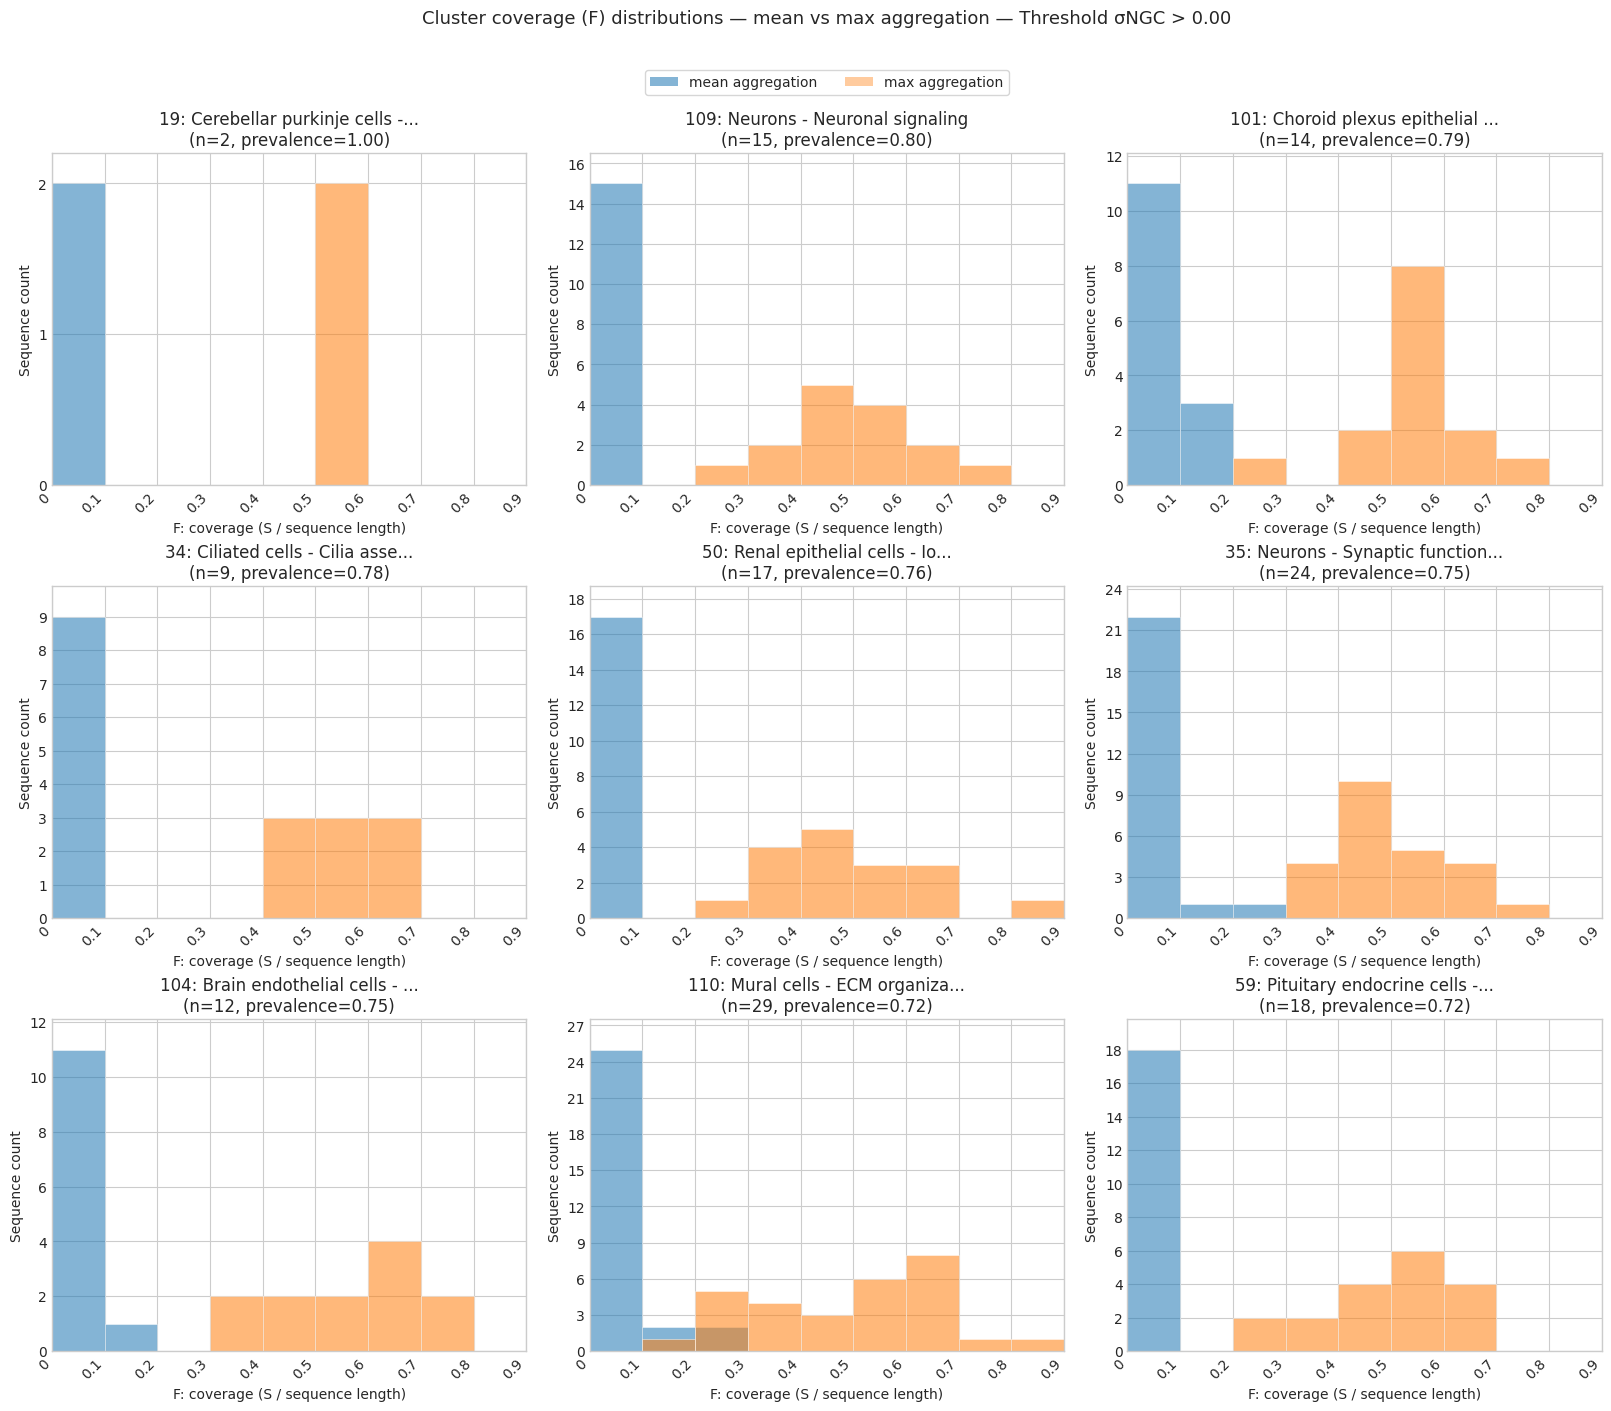

In [98]:
# coverage
plot_overlay_grid(
    overlay_pairs,
    make_metric_overlay_draw(
        sequence_f_values,
        "F: coverage (S / sequence length)",
        "All sequences have F = 0",
    ),
    "Cluster coverage (F) distributions — mean vs max aggregation",
)
